# Lecture 4 — Events, phase, and coupling from data


In [1]:
# Housekeeping code...
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import linear_sum_assignment
from scipy.signal import (
    correlate,
    correlation_lags,
    find_peaks,
    hilbert,
    savgol_filter,
)
from IPython.display import Video, display

if Path("../media").exists():
    MEDIA = Path("../media")
    MOUSE_DATA = Path("../data/mouse")
elif Path("media").exists():
    MEDIA = Path("media")
    MOUSE_DATA = Path("data/mouse")
else:
    raise FileNotFoundError("Run this notebook from the course repository.")

FIREFLY_DISPLAY_VIDEO = MEDIA / "firefly-synchrony.mp4"
FIREFLY_ANALYSIS_VIDEO = MEDIA / "firefly-synchrony-analysis.mp4"
LEAP_VIDEO = MEDIA / "mouse_pose.mp4"
MOUSE_VIDEO = MEDIA / "mouse-running.mp4"
MOUSE_FPS = 80.0
TAU = 2 * np.pi

BLUE = "#3B6FB6"
ORANGE = "#D97706"
GOLD = "#C9A227"
PINK = "#B64E77"
OLIVE = "#718355"
INK = "#263238"
GREY = "#9AA0A6"
LIGHT = "#E7EAED"
PAW_ORDER = ["LF", "RF", "LH", "RH"]
PAW_INDEX = {limb: index for index, limb in enumerate(PAW_ORDER)}
LIMB_COLORS = {"LF": BLUE, "RF": ORANGE, "LH": PINK, "RH": OLIVE}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 11,
})

def movie(path, width=760):
    return Video(
        str(path),
        embed=False,
        width=width,
        html_attributes="controls loop muted playsinline",
    )

def video_properties(path):
    capture = cv2.VideoCapture(str(path))
    if not capture.isOpened():
        raise FileNotFoundError(path)
    properties = {
        "fps": capture.get(cv2.CAP_PROP_FPS),
        "n_frames": int(capture.get(cv2.CAP_PROP_FRAME_COUNT)),
        "width": int(capture.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    capture.release()
    return properties

def read_rgb_frame(path, frame_index):
    capture = cv2.VideoCapture(str(path))
    capture.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
    ok, frame_bgr = capture.read()
    capture.release()
    if not ok:
        raise IndexError(f"Could not read frame {frame_index} from {path}")
    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

def detect_frame(rgb_frame, threshold=20, min_area=5):
    gray = cv2.cvtColor(rgb_frame, cv2.COLOR_RGB2GRAY)
    mask = (gray > threshold).astype(np.uint8)
    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        mask, connectivity=8
    )

    rows = []
    for label in range(1, n_labels):
        area = int(stats[label, cv2.CC_STAT_AREA])
        if area < min_area:
            continue
        x_px, y_px = centroids[label]
        integrated_intensity = int(gray[labels == label].sum())
        rows.append({
            "label": label,
            "x_px": x_px,
            "y_px": y_px,
            "intensity": integrated_intensity,
            "area": area,
        })
    return gray, mask, labels, pd.DataFrame(rows)

def detect_movie(path, threshold=20, min_area=5):
    properties = video_properties(path)
    capture = cv2.VideoCapture(str(path))
    rows = []
    frame_index = 0

    while True:
        ok, frame_bgr = capture.read()
        if not ok:
            break
        gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
        mask = (gray > threshold).astype(np.uint8)
        n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            mask, connectivity=8
        )

        for label in range(1, n_labels):
            area = int(stats[label, cv2.CC_STAT_AREA])
            if area < min_area:
                continue
            x_px, y_px = centroids[label]
            rows.append({
                "x_px": x_px,
                "y_px": y_px,
                "frame": frame_index,
                "time_s": frame_index / properties["fps"],
                "intensity": int(gray[labels == label].sum()),
                "area": area,
            })
        frame_index += 1

    capture.release()
    table = pd.DataFrame(rows)
    table.index.name = "d"
    return table, properties

def link_detections(detections, max_step_px=12):
    linked = detections.copy()
    linked["streak"] = -1
    next_streak = 0
    previous_frame = None
    previous_points = np.empty((0, 2))
    previous_streaks = np.empty(0, dtype=int)

    for frame_index, frame_rows in linked.groupby("frame", sort=True):
        current_indices = frame_rows.index.to_numpy()
        current_points = frame_rows[["x_px", "y_px"]].to_numpy()
        current_streaks = np.full(len(frame_rows), -1, dtype=int)

        if (
            previous_frame is not None
            and frame_index == previous_frame + 1
            and len(previous_points)
            and len(current_points)
        ):
            distances = np.linalg.norm(
                previous_points[:, None, :] - current_points[None, :, :],
                axis=2,
            )
            n_previous, n_current = distances.shape
            unmatched_cost = max_step_px / 2
            blocked_cost = 10 * max_step_px
            costs = np.full(
                (n_previous + n_current, n_previous + n_current),
                blocked_cost,
            )
            costs[:n_previous, :n_current] = np.where(
                distances <= max_step_px, distances, blocked_cost
            )
            costs[:n_previous, n_current:] = np.eye(n_previous) * (
                unmatched_cost - blocked_cost
            ) + blocked_cost
            costs[n_previous:, :n_current] = np.eye(n_current) * (
                unmatched_cost - blocked_cost
            ) + blocked_cost
            costs[n_previous:, n_current:] = 0
            previous_match, current_match = linear_sum_assignment(costs)
            for previous_index, current_index in zip(
                previous_match, current_match
            ):
                if (
                    previous_index < n_previous
                    and current_index < n_current
                    and distances[previous_index, current_index] <= max_step_px
                ):
                    current_streaks[current_index] = (
                        previous_streaks[previous_index]
                    )

        for current_index in np.flatnonzero(current_streaks < 0):
            current_streaks[current_index] = next_streak
            next_streak += 1

        linked.loc[current_indices, "streak"] = current_streaks
        previous_frame = frame_index
        previous_points = current_points
        previous_streaks = current_streaks

    linked["streak"] = linked["streak"].astype(int)
    return linked

def make_flash_onset_table(linked_detections, fps, min_frames=2):
    rows = []
    for streak_id, streak in linked_detections.groupby("streak", sort=True):
        streak = streak.sort_values("frame")
        if len(streak) < min_frames:
            continue
        onset = streak.iloc[0]
        steps = np.diff(streak[["x_px", "y_px"]].to_numpy(), axis=0)
        rows.append({
            "streak": streak_id,
            "x_px": onset["x_px"],
            "y_px": onset["y_px"],
            "frame": int(onset["frame"]),
            "time_s": onset["time_s"],
            "duration_frames": len(streak),
            "duration_s": len(streak) / fps,
            "path_length_px": np.linalg.norm(steps, axis=1).sum(),
        })
    table = pd.DataFrame(rows)
    table.index.name = "e"
    return table

def event_phase(n_samples, event_indices):
    event_indices = np.asarray(event_indices, dtype=int)
    phase = np.full(n_samples, np.nan)
    for cycle, (start, stop) in enumerate(
        zip(event_indices[:-1], event_indices[1:])
    ):
        indices = np.arange(start, stop + 1)
        phase[indices] = TAU * (
            cycle + (indices - start) / (stop - start)
        )
    return phase

def circular_summary(phi):
    z = np.mean(np.exp(1j * np.asarray(phi)))
    return np.angle(z), np.abs(z)

def normalized_cross_correlation(x_i, x_j):
    x_i = (np.asarray(x_i) - np.mean(x_i)) / np.std(x_i)
    x_j = (np.asarray(x_j) - np.mean(x_j)) / np.std(x_j)
    values = correlate(x_j, x_i, mode="full") / x_i.size
    lags = correlation_lags(x_j.size, x_i.size, mode="full")
    return lags, values

def colored_line(ax, x, y, color_values, linewidth=3):
    points = np.column_stack([x, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    collection = LineCollection(
        segments,
        cmap="viridis",
        norm=plt.Normalize(np.min(color_values), np.max(color_values)),
        linewidth=linewidth,
    )
    collection.set_array(np.asarray(color_values[:-1]))
    ax.add_collection(collection)
    ax.autoscale_view()
    return collection

def draw_phase_vectors(ax, phases, harmonic=1):
    transformed = harmonic * np.asarray(phases)
    circle = np.linspace(0, TAU, 400)
    ax.plot(np.cos(circle), np.sin(circle), color=LIGHT, lw=2)
    for phase, color in zip(transformed, [LIMB_COLORS[limb] for limb in PAW_ORDER]):
        ax.arrow(
            0, 0, np.cos(phase), np.sin(phase),
            width=0.012, head_width=0.09,
            length_includes_head=True, color=color, alpha=0.9,
        )
    z_m = np.mean(np.exp(1j * transformed))
    ax.arrow(
        0, 0, z_m.real, z_m.imag,
        width=0.025, head_width=0.12,
        length_includes_head=True, color=INK, zorder=5,
    )
    ax.set(xlim=(-1.15, 1.15), ylim=(-1.15, 1.15))
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(rf"$m={harmonic}:\ R_{harmonic}={abs(z_m):.2f}$")


## More than pretty pictures

Much of the data we will discuss in this course ultimately comes from images recorded with a camera. We will need to do some analysis to convert these images to time series data.

In [2]:
movie(FIREFLY_DISPLAY_VIDEO)


> ### How can we turn the movie into a multidimensional time series of flash events?

Let's look at one frame: 960.

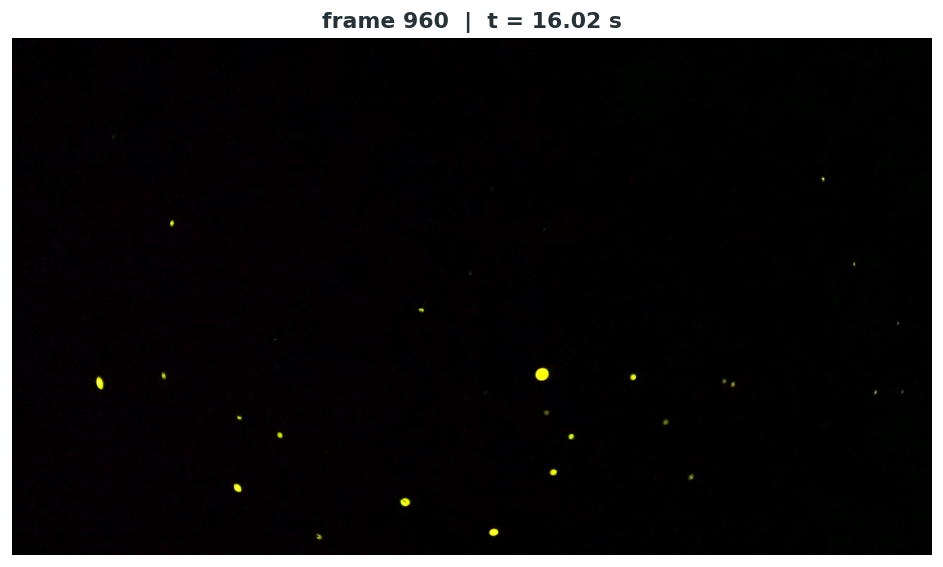

In [3]:
firefly_properties = video_properties(FIREFLY_ANALYSIS_VIDEO)
DEMO_FRAME = 960
demo_rgb = read_rgb_frame(FIREFLY_ANALYSIS_VIDEO, DEMO_FRAME)

fig, ax = plt.subplots(figsize=(10, 5.6))
ax.imshow(demo_rgb)
ax.set_title(
    f"frame {DEMO_FRAME}  |  t = "
    f"{DEMO_FRAME / firefly_properties['fps']:.2f} s"
)
ax.axis("off")
plt.show()


### Threshold bright pixels

$$
\chi_t(x,y)=\mathbf 1_{\{I_t(x,y)>h\}}.
$$



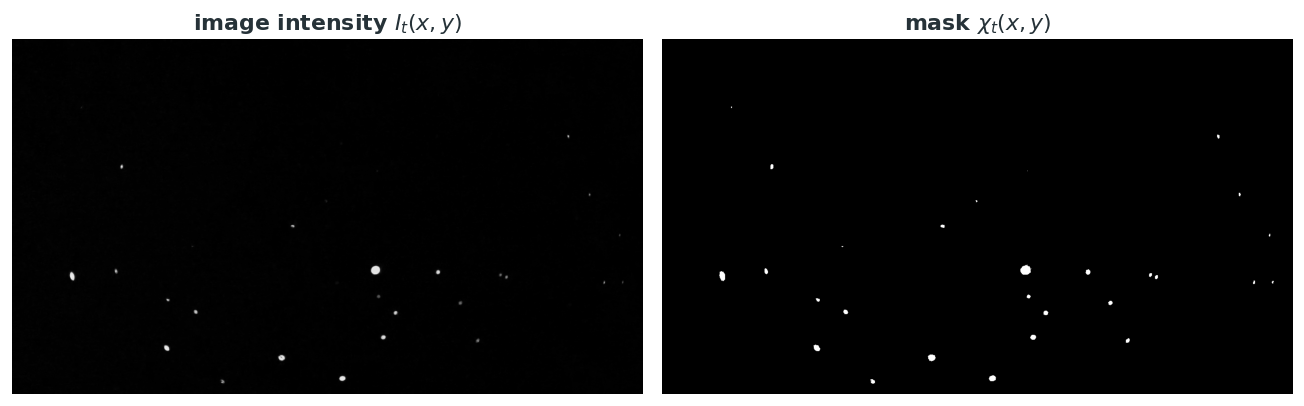

In [4]:
DETECTION_THRESHOLD = 20
demo_gray, demo_mask, demo_labels, demo_components_all = detect_frame(
    demo_rgb,
    threshold=DETECTION_THRESHOLD,
    min_area=5,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].imshow(demo_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(r"image intensity $I_t(x,y)$")
axes[1].imshow(demo_mask, cmap="gray")
axes[1].set_title(r"mask $\chi_t(x,y)$")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()


### Group connected pixels

A flash occupies several neighboring pixels. Pixels sharing an edge or corner belong to the same *connected component* $\mathcal C_d$.

For each component $d$, we can calculate its area, total brightness, and centroid position:

$$
a_d=|\mathcal C_d|,
\qquad
I_d=\sum_{(x,y)\in\mathcal C_d}I_t(x,y),
$$

$$
x_d=\frac{1}{a_d}\sum_{(x,y)\in\mathcal C_d}x.
$$

$$
y_d=\frac{1}{a_d}\sum_{(x,y)\in\mathcal C_d}y.
$$


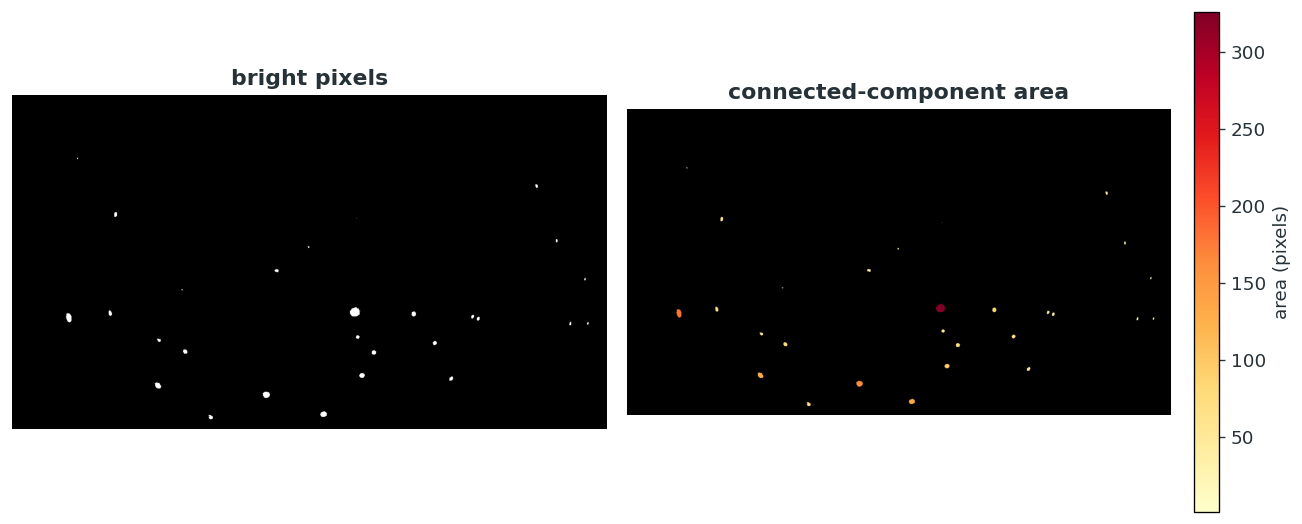

In [5]:
component_areas = np.bincount(demo_labels.ravel())
area_by_pixel = component_areas[demo_labels].astype(float)
area_by_pixel[demo_labels == 0] = np.nan

area_cmap = plt.colormaps["YlOrRd"].copy()
area_cmap.set_bad("black")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].imshow(demo_mask, cmap="gray")
axes[0].set_title("bright pixels")
area_image = axes[1].imshow(
    area_by_pixel,
    cmap=area_cmap,
    vmin=1,
    vmax=component_areas[1:].max(),
)
axes[1].set_title("connected-component area")
colorbar = fig.colorbar(
    area_image, ax=axes[1], fraction=0.046, pad=0.04
)
colorbar.set_label("area (pixels)")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()


### We will add each component to a table of observations

$$
{\rm Detections\ }
=\{(x_d,y_d,t_d,I_d,a_d)\}_{d=1}^{n_{\mathrm{det}}}.
$$

In [6]:
firefly_detections, firefly_properties = detect_movie(
    FIREFLY_ANALYSIS_VIDEO,
    threshold=DETECTION_THRESHOLD
)

print(
    f"{firefly_properties['n_frames']:,} frames  →  "
    f"{len(firefly_detections):,} component observations"
)
display(
    firefly_detections.loc[
        firefly_detections["frame"] == DEMO_FRAME
    ]
    .head(8)
    .round({"x_px": 1, "y_px": 1, "time_s": 3})
)


1,918 frames  →  9,153 component observations


,x_px,y_px,frame,time_s,intensity,area
d,,,,,,
4854,140.5,138.0,960,16.016,184,6
4855,1128.1,197.3,960,16.016,2938,33
4856,222.4,258.5,960,16.016,6356,54
4857,1171.3,314.9,960,16.016,1572,23
4858,637.6,328.4,960,16.016,294,11
4859,568.9,379.2,960,16.016,4723,44
4860,1232.1,397.4,960,16.016,720,14
4861,365.5,420.3,960,16.016,217,6


### But ... each firefly flash spans several frames


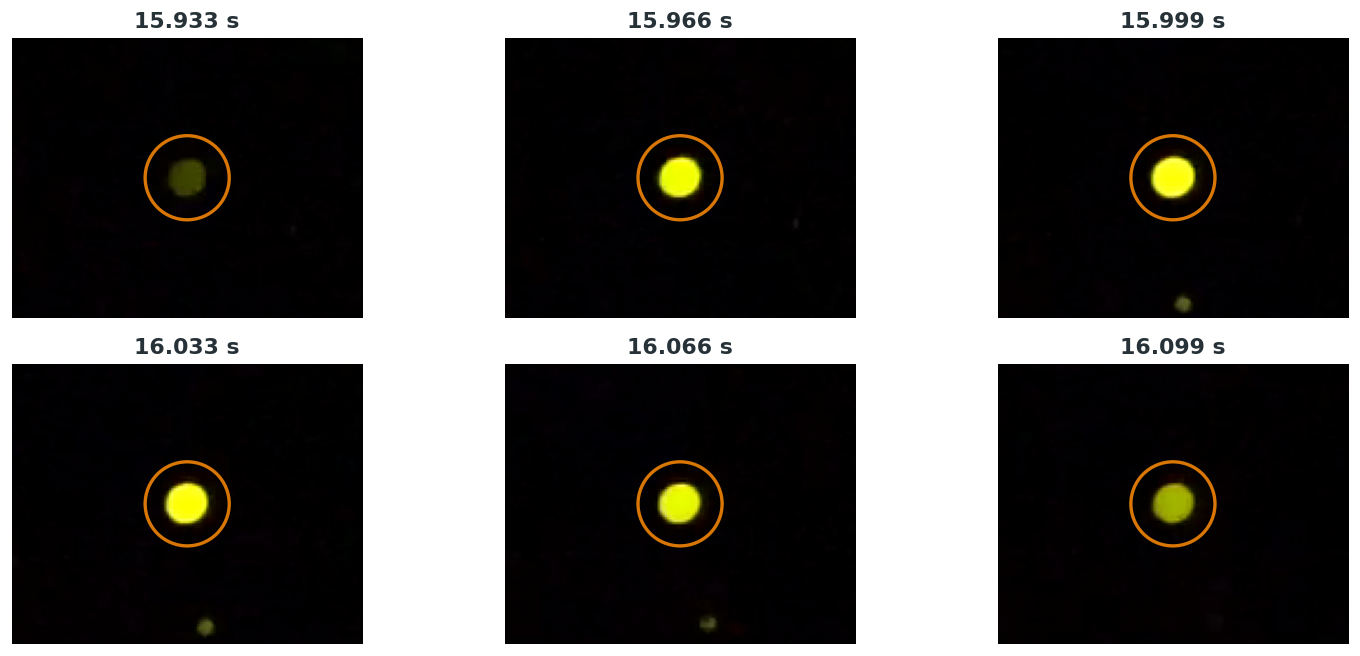

In [7]:
streak_frames = np.arange(955, 966, 2)
reference_rows = firefly_detections.loc[
    firefly_detections["frame"] == DEMO_FRAME
]
reference = reference_rows.loc[reference_rows["intensity"].idxmax()]

fig, axes = plt.subplots(2, 3, figsize=(13, 5.6))
for ax, frame_index in zip(axes.flat, streak_frames):
    frame = read_rgb_frame(FIREFLY_ANALYSIS_VIDEO, frame_index)
    frame_rows = firefly_detections.loc[
        firefly_detections["frame"] == frame_index
    ].copy()
    distance_squared = (
        (frame_rows["x_px"] - reference["x_px"]) ** 2
        + (frame_rows["y_px"] - reference["y_px"]) ** 2
    )
    nearest = frame_rows.loc[distance_squared.idxmin()]
    ax.imshow(frame)
    ax.add_patch(
        Circle(
            (nearest["x_px"], nearest["y_px"]),
            radius=18,
            fill=False,
            color=ORANGE,
            lw=2,
        )
    )
    ax.set_title(f"{frame_index / firefly_properties['fps']:.3f} s")
    ax.set_xlim(nearest["x_px"] - 75, nearest["x_px"] + 75)
    ax.set_ylim(nearest["y_px"] + 60, nearest["y_px"] - 60)
    ax.axis("off")
fig.tight_layout()
plt.show()


### Link observations into flash streaks (tracking)

We need to be a little careful because the flies can move a bit while they are flashing. We will match spots in consecutive frames if they move less than
$$
r_{\max}=12\ \text{pixels}.
$$


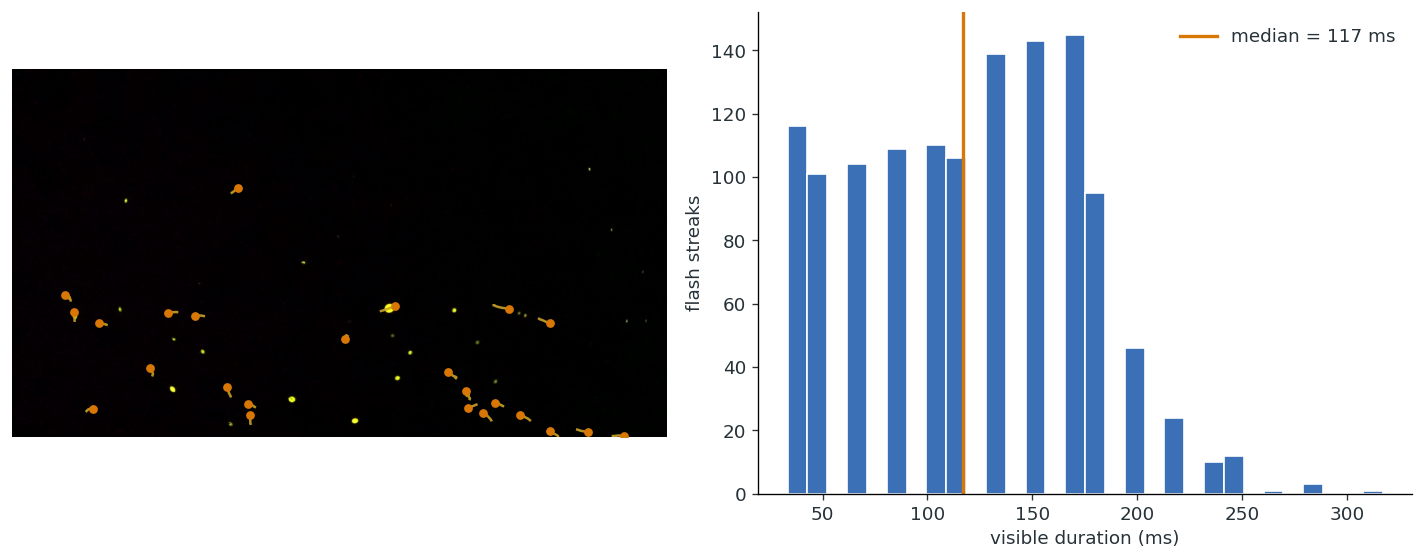

In [8]:
MAX_LINK_DISTANCE_PX = 12
linked_detections = link_detections(
    firefly_detections,
    max_step_px=MAX_LINK_DISTANCE_PX,
)
streak_summary = make_flash_onset_table(
    linked_detections,
    fps=firefly_properties["fps"],
    min_frames=1,
)

multiframe_streaks = streak_summary.loc[
    streak_summary["duration_frames"] >= 2
]
trajectory_streaks = (
    multiframe_streaks.loc[
        multiframe_streaks["duration_frames"] <= 15
    ]
    .nlargest(24, "path_length_px")["streak"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].imshow(demo_rgb)
for streak_id in trajectory_streaks:
    trajectory = linked_detections.loc[
        linked_detections["streak"] == streak_id
    ].sort_values("frame")
    axes[0].plot(
        trajectory["x_px"], trajectory["y_px"],
        color=GOLD, lw=1.5, alpha=0.9,
    )
    axes[0].scatter(
        trajectory.iloc[0]["x_px"],
        trajectory.iloc[0]["y_px"],
        color=ORANGE, s=18, zorder=3,
    )
axes[0].axis("off")

duration_ms = 1000 * multiframe_streaks["duration_s"]
axes[1].hist(duration_ms, bins=30, color=BLUE, edgecolor="white")
axes[1].axvline(
    duration_ms.median(), color=ORANGE, lw=2,
    label=f"median = {duration_ms.median():.0f} ms",
)
axes[1].set(
    xlabel="visible duration (ms)",
    ylabel="flash streaks",
)
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()


### We want to keep track of flash onset

Note: A streak present in frame 0 has no observed onset and is thus excluded.


In [9]:
MIN_STREAK_FRAMES = 2
firefly_onsets = make_flash_onset_table(
    linked_detections,
    fps=firefly_properties["fps"],
    min_frames=MIN_STREAK_FRAMES,
)
firefly_onsets = (
    firefly_onsets.loc[firefly_onsets["frame"] > 0]
    .reset_index(drop=True)
)
firefly_onsets.index.name = "e"

print(
    f"{len(firefly_detections):,} component observations  →  "
    f"{len(firefly_onsets):,} flash onsets"
)
display(
    firefly_onsets.head(8).round({
        "x_px": 1, "y_px": 1, "time_s": 3,
        "duration_s": 3, "path_length_px": 1,
    })
)


9,153 component observations  →  1,252 flash onsets


,streak,x_px,y_px,frame,time_s,duration_frames,duration_s,path_length_px
e,,,,,,,,
0,17,920.8,529.1,2,0.033,2,0.033,0.7
1,18,321.8,122.4,3,0.050,9,0.150,5.7
2,19,355.4,179.5,4,0.067,5,0.083,0.7
3,20,335.7,218.9,4,0.067,5,0.083,1.6
4,21,246.0,263.0,4,0.067,9,0.150,1.3
5,22,328.4,302.2,4,0.067,8,0.133,2.6
6,23,466.3,131.5,5,0.083,9,0.150,2.6
7,24,482.4,172.9,5,0.083,6,0.100,3.9


### Count flash onsets in every frame

This is (essentially) the data we looked at in Lecture 2!

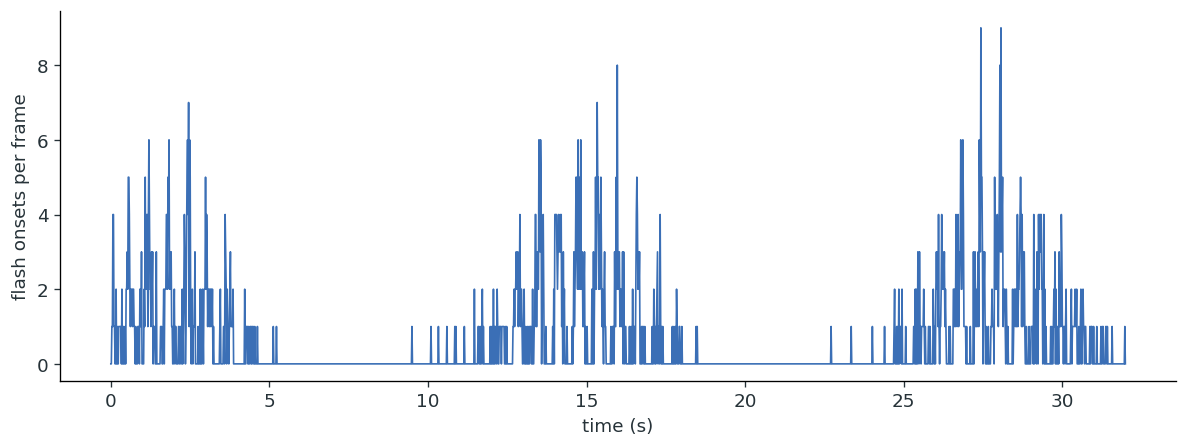

In [10]:
frame_counts = (
    firefly_onsets.groupby("frame")
    .size()
    .reindex(range(firefly_properties["n_frames"]), fill_value=0)
    .to_numpy()
)
firefly_time = np.arange(frame_counts.size) / firefly_properties["fps"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(firefly_time, frame_counts, color=BLUE, lw=1)
ax.set(
    xlabel="time (s)",
    ylabel="flash onsets per frame"
)
plt.show()


## Mouse locomotion

Let's move to a system with a clearer periodic signal so we can explore the Kuramoto model.

In [11]:
movie(MOUSE_VIDEO, width=520)

### Track the four paws

Keypoint pose tracking using CNNs



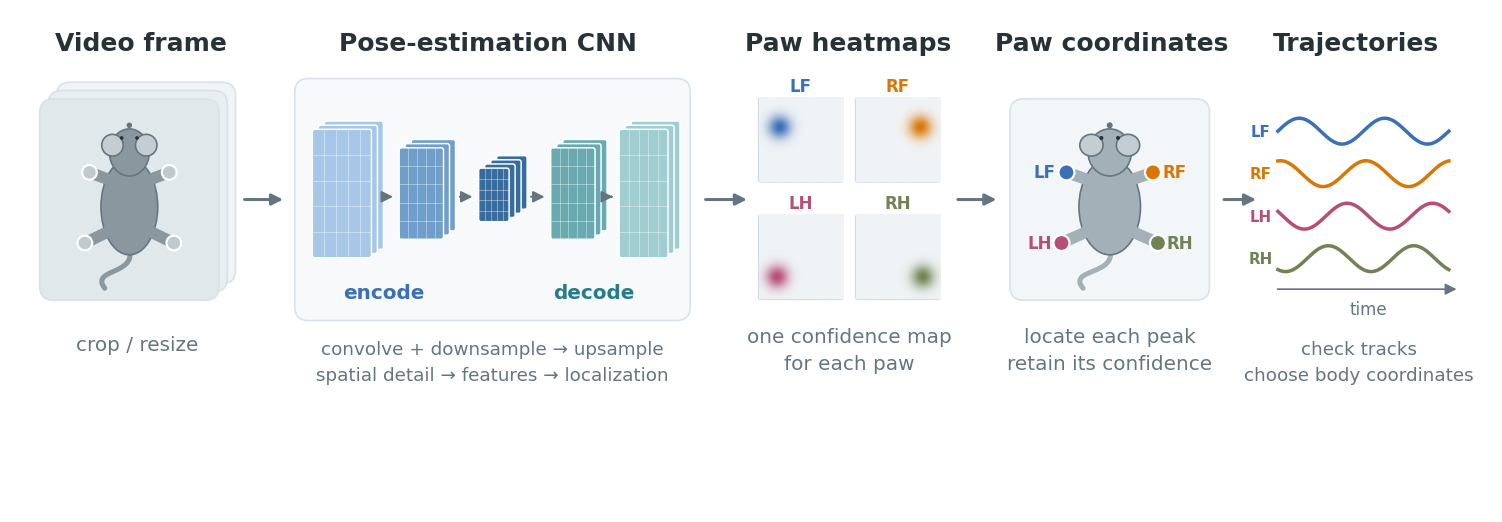

In [12]:
from matplotlib.patches import Circle, Ellipse, FancyArrowPatch, FancyBboxPatch
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from matplotlib.colors import LinearSegmentedColormap

fig, ax = plt.subplots(figsize=(16, 5.4))
fig.patch.set_facecolor('white')
ax.set(xlim=(0, 16), ylim=(0, 5.4), aspect='equal')
ax.axis('off')
muted = '#647580'
teal = '#287C87'

def box(x, y, w, h, face='#F3F6F8', edge='#D9E2E7', lw=1, radius=.15):
    p = FancyBboxPatch((x, y), w, h,
                      boxstyle=f'round,pad=0,rounding_size={radius}',
                      facecolor=face, edgecolor=edge, lw=lw)
    ax.add_patch(p)
    return p

def label(x, y, text, size=13, color=INK, weight='normal', **kw):
    return ax.text(x, y, text, ha='center', va='center', fontsize=size,
                   color=color, fontweight=weight, **kw)

def arrow(start, end, color=muted, lw=1.8, **kw):
    p = FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=14,
                        color=color, lw=lw, **kw)
    ax.add_patch(p)

# One consistent top-down mouse and paw geometry throughout the schematic.
paws = {'LF': (.24, .65), 'RF': (.76, .65),
        'LH': (.21, .26), 'RH': (.79, .26)}

def mouse(x, y, w, h, detected=False):
    def xy(u, v): return (x + w*u, y + h*v)
    body = '#A4B0B8' if detected else '#8A979F'
    tail = MplPath([xy(.5, .23), xy(.55, .08), xy(.24, .12), xy(.34, .01)],
                   [MplPath.MOVETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4])
    ax.add_patch(PathPatch(tail, fill=False, color=body, lw=3, capstyle='round'))
    for name, (u, v) in paws.items():
        start = xy(.43 if u < .5 else .57, .59 if v > .5 else .35)
        end = xy(u, v)
        ax.plot([start[0], end[0]], [start[1], end[1]], color=body, lw=7,
                solid_capstyle='round', zorder=2)
    ax.add_patch(Ellipse(xy(.5, .46), .37*w, .53*h, facecolor=body, edgecolor='#657681', lw=1))
    ax.add_patch(Ellipse(xy(.5, .76), .26*w, .26*h, facecolor=body, edgecolor='#657681', lw=1))
    for u in [.39, .61]:
        ax.add_patch(Ellipse(xy(u, .80), .14*w, .12*h, facecolor='#C4CDD2', edgecolor='#657681', lw=1))
    for u in [.45, .55]:
        ax.add_patch(Circle(xy(u, .84), .012*w, facecolor=INK, edgecolor='none'))
    ax.add_patch(Circle(xy(.5, .91), .018*w, facecolor=muted, edgecolor='none'))
    for name, (u, v) in paws.items():
        ax.add_patch(Circle(xy(u, v), .048*w,
                            facecolor=LIMB_COLORS[name] if detected else '#C0C9CE',
                            edgecolor='white', lw=1.3, zorder=4))
        if detected:
            label(x+w*(u+(-.13 if u<.5 else .13)), y+h*v, name, 10,
                  color=LIMB_COLORS[name], weight='bold')

# Inference: the same learned network is applied to each new frame.
centers = [1.4, 5.15, 9.05, 11.9, 14.55]
heads = ['Video frame', 'Pose-estimation CNN', 'Paw heatmaps', 'Paw coordinates', 'Trajectories']
for x, head in zip(centers, heads):
    label(x, 5.05, head, 15, weight='bold')

# Unlabeled input, with a hint of the surrounding video frames.
box(.48, 2.45, 1.94, 2.18, '#F1F4F6')
box(.39, 2.36, 1.94, 2.18, '#E9EEF1')
box(.3, 2.27, 1.94, 2.18, '#E1E8EC')
mouse(.44, 2.38, 1.66, 1.96)
label(1.35, 1.79, 'crop / resize', 12, color=muted)
arrow((2.48, 3.36), (2.97, 3.36))

# Schematic encoder-decoder; grids represent spatial maps and depth represents channels.
box(3.06, 2.05, 4.28, 2.62, '#F7F9FB', '#D9E3EB')
def features(x, y, w, h, color, depth=3):
    for k in range(depth-1, -1, -1):
        dx, dy = .065*k, .045*k
        box(x+dx, y+dy, w, h, color, '#FFFFFF', .9, .025)
    for f in np.linspace(.2, .8, 4):
        ax.plot([x+w*f]*2, [y, y+h], color='white', alpha=.38, lw=.6)
        ax.plot([x, x+w], [y+h*f]*2, color='white', alpha=.38, lw=.6)

features(3.25, 2.73, .64, 1.39, '#A6C7E7')
features(4.19, 2.93, .48, .99, '#6E9EC9')
features(5.05, 3.12, .33, .58, '#386C9C', 4)
features(5.83, 2.93, .48, .99, '#69A9B0')
features(6.57, 2.73, .53, 1.39, '#A0CDD0')
for x0, x1 in [(4.01,4.16), (4.81,5.02), (5.58,5.8), (6.45,6.54)]:
    arrow((x0,3.39),(x1,3.39),lw=1.2)
label(4.02, 2.35, 'encode', 12, color=BLUE, weight='bold')
label(6.30, 2.35, 'decode', 12, color=teal, weight='bold')
label(5.2, 1.60, 'convolve + downsample → upsample\nspatial detail → features → localization', 11, color=muted, linespacing=1.6)
arrow((7.47, 3.36), (7.99, 3.36))

# Each map is registered to the same image; these are confidence, not normalized probability, maps.
grid = np.linspace(0, 1, 70)
uu, vv = np.meshgrid(grid, grid)
for (name, color), (x,y) in zip(LIMB_COLORS.items(), [(8.08,3.55),(9.13,3.55),(8.08,2.28),(9.13,2.28)]):
    u, v = paws[name]
    heat = np.exp(-((uu-u)**2+(vv-v)**2)/(2*.095**2))
    cmap = LinearSegmentedColormap.from_list('paw', ['#F0F3F5', color])
    ax.imshow(heat, extent=(x,x+.91,y,y+.91), origin='lower', cmap=cmap,
              vmin=0, vmax=1, interpolation='bilinear', zorder=2)
    box(x, y, .91, .91, 'none', '#D1DCE2', .9, .02)
    label(x+.455, y+1.04, name, 10, color=color, weight='bold')
label(9.06, 1.73, 'one confidence map\nfor each paw', 12, color=muted, linespacing=1.5)
arrow((10.2,3.36),(10.69,3.36))

box(10.8,2.27,2.16,2.18,'#F3F6F8')
mouse(10.98,2.38,1.80,1.96,detected=True)
label(11.88,1.73,'locate each peak\nretain its confidence',12,color=muted,linespacing=1.5)
arrow((13.08,3.36),(13.5,3.36))

# Illustrative traces make the hand-off from per-frame localization to time series explicit.
t_example = np.linspace(0, 1, 160)
for j,(name,color) in enumerate(LIMB_COLORS.items()):
    y = 4.10 - .46*j
    trace = .14*np.sin(2*np.pi*(2.0*t_example + j*.22))
    ax.plot(13.70+1.85*t_example, y+trace, color=color, lw=2.1)
    label(13.51,y,name,9,color=color,weight='bold')
arrow((13.66,2.39),(15.67,2.39),lw=1)
label(14.68,2.17,'time',10,color=muted)
label(14.58,1.60,'check tracks\nchoose body coordinates',11,color=muted,linespacing=1.6)

plt.show()


In [13]:
movie(LEAP_VIDEO, width=960)

### Paw trajectories

Paw numbers: $1=\mathrm{LF}$, $2=\mathrm{RF}$, $3=\mathrm{LH}$, $4=\mathrm{RH}$.

We will use the $y$-coordinate (along the body axis) of each paw's displacement.

If we subtract the mean of each, we can see that the four paws are coordinated in their dynamics.

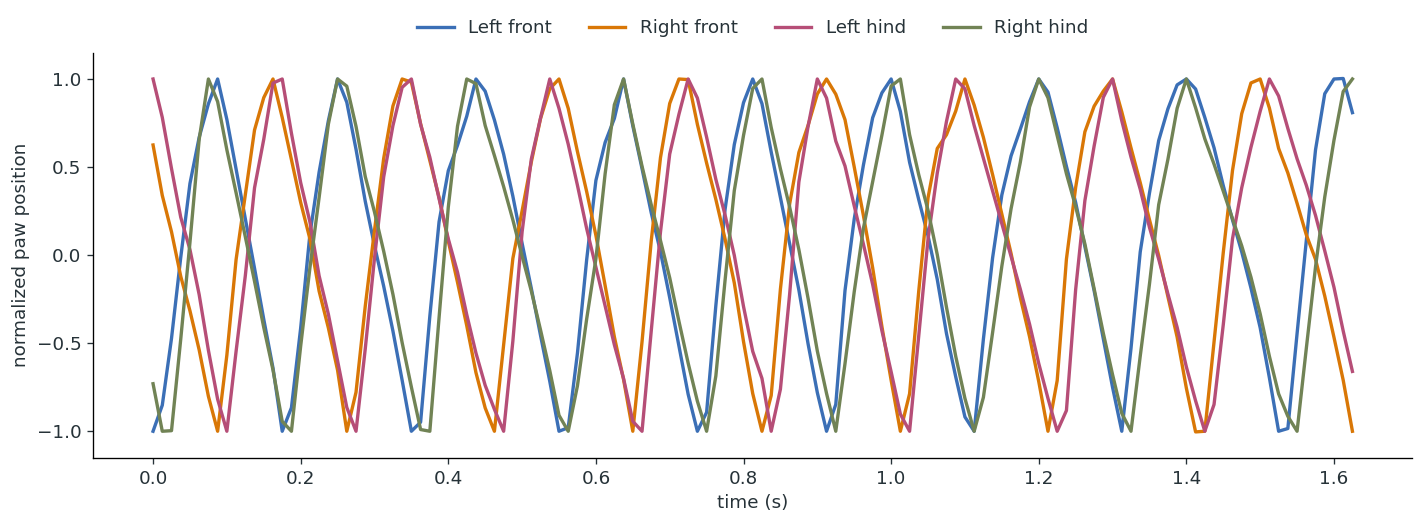

In [14]:
mouse = pd.read_csv(MOUSE_DATA / "mouse-bout-08.csv")
limbs = PAW_ORDER.copy()
paw_names = {
    "LF": "Left front",
    "RF": "Right front",
    "LH": "Left hind",
    "RH": "Right hind",
}
mouse_time = np.arange(len(mouse)) / MOUSE_FPS

fig, ax = plt.subplots(figsize=(12, 4.5))
for limb in limbs:
    ax.plot(
        mouse_time, mouse[limb],
        color=LIMB_COLORS[limb], lw=2, label=paw_names[limb],
    )
ax.set(
    xlabel="time (s)",
    ylabel="normalized paw position",
    ylim=(-1.15, 1.15),
)
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02),
    ncol=4, frameon=False, borderaxespad=0,
)
fig.tight_layout()
plt.show()

### Cross-correlation measures temporal offset

We can measure the temporal offset between pairs of paws using the *cross-correlation*.

First center and scale (z-score) each trajectory:

$$
\tilde x_i(t)
=\frac{x_i(t)-\langle x_i(t)\rangle_t}{\sigma_i}.
$$

$\sigma_i$ is the standard deviation of paw $i$'s trajectory over time.

For each trial lag $\tau$, shift the trajectory of paw $j$, multiply the aligned samples, and average over time:

$$
C_{ij}(\tau)
=\left\langle
\tilde x_i(t)\tilde x_j(t+\tau)
\right\rangle_t.
$$

$C_{ij}(\tau)\approx 1$ when the shifted trajectories align and $C_{ij}(\tau)\approx-1$ when they are inverted. 

The lag that best aligns the traces is

$$
\tau_{ij}^{*}=\operatorname*{arg\,max}_{\tau}C_{ij}(\tau).
$$

- positive $\tau_{ij}^{*}$ means paw $j$ follows paw $i$
- a negative value means it leads.

A peak at $\tau=0$ indicates simultaneous motion, while a peak near half a stride time indicates alternation.

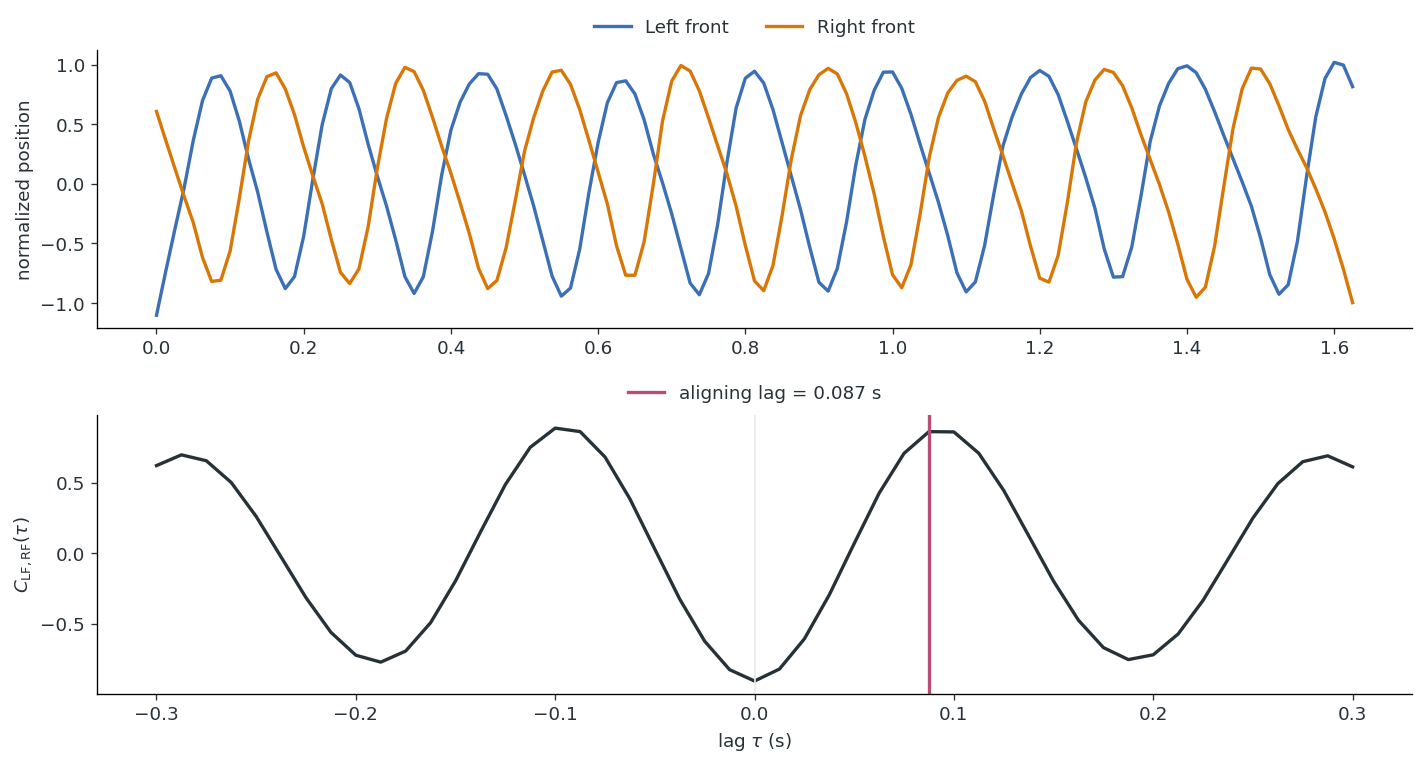

In [15]:
mouse_smoothed = {
    limb: savgol_filter(mouse[limb].to_numpy(), 7, 2)
    for limb in limbs
}

lag_samples, lf_rf_correlation = normalized_cross_correlation(
    mouse_smoothed["LF"], mouse_smoothed["RF"]
)
lag_seconds = lag_samples / MOUSE_FPS
lag_window = np.abs(lag_seconds) <= 0.30
positive_half_cycle = (lag_seconds > 0) & (lag_seconds <= 0.18)
best_positive_lag = lag_seconds[positive_half_cycle][
    np.argmax(lf_rf_correlation[positive_half_cycle])
]

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5))
axes[0].plot(
    mouse_time, mouse_smoothed["LF"],
    color=BLUE, lw=2, label=paw_names["LF"],
)
axes[0].plot(
    mouse_time, mouse_smoothed["RF"],
    color=ORANGE, lw=2, label=paw_names["RF"],
)
axes[0].set(ylabel="normalized position")
axes[0].legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02),
    ncol=2, frameon=False, borderaxespad=0,
)

axes[1].plot(
    lag_seconds[lag_window], lf_rf_correlation[lag_window],
    color=INK, lw=2,
)
axes[1].axvline(0, color=LIGHT, lw=1)
axes[1].axvline(
    best_positive_lag, color=PINK, lw=2,
    label=f"aligning lag = {best_positive_lag:.3f} s",
)
axes[1].set(
    xlabel=r"lag $\tau$ (s)",
    ylabel=r"$C_{\rm LF,RF}(\tau)$",
)
axes[1].legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02),
    frameon=False, borderaxespad=0,
)
fig.tight_layout()
plt.show()

## Measuring phase

The traces above represent the physical position of the paws in space. As the animal goes through one gait cycle, it repeats the same pattern in space, an *orbit*. 

Because the animal repeats motion around this orbit, we can search for a phase variable that describes where on the orbit the paw is.

### The Hilbert transform

The Hilbert transform can be used to calculate a phase variable for a periodic one-dimensional signal by constructing a second signal in *quadrature* with the first. For example, it turns a cosine into a sine, shifting it by one-quarter period:

$$
x(t)=\cos(\omega t)
\qquad\Longrightarrow\qquad
\mathcal H[x](t)=\sin(\omega t).
$$

For a general (zero-mean centered) signal $x_i(t)$, the Hilbert transform is defined in Fourier space by

$$
\mathcal F\{\mathcal H[x_i](t)\}
=-i\,\operatorname{sgn}(\omega)X_i(\omega),
$$

where $X_i(\omega)=\mathcal F\{x_i(t)\}$.

- Positive-frequency components are multiplied by $-i=e^{-i\pi/2}$, shifting their phase by $-\pi/2$
- Negative-frequency components are multiplied by $+i=e^{i\pi/2}$, shifting their phase by $+\pi/2$. 

The same operation can be written in the time domain as a principal-value integral:

$$
\mathcal H[x_i](t)
=\frac{1}{\pi}\operatorname{PV}\!\int_{-\infty}^{\infty}
\frac{x_i(\tau)}{t-\tau}\,d\tau.
$$

*(PV means Cauchy principal value. The kernel $1/(t-\tau)$ diverges at $\tau=t$, so omit a symmetric interval $(t-\epsilon,t+\epsilon)$, integrate on both sides, and then take $\epsilon\to0$. The equal-and-opposite singular contributions cancel.)*



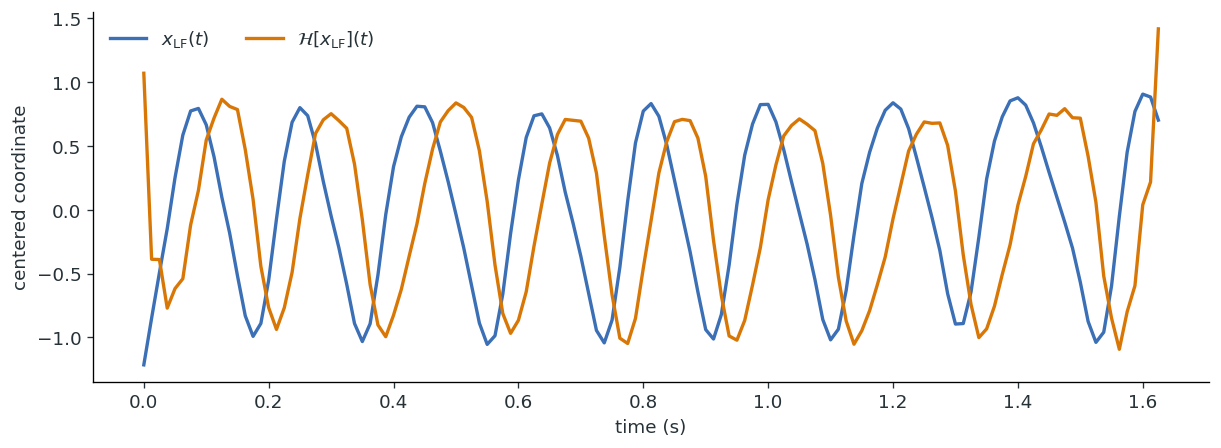

In [16]:
mouse_centered = {
    limb: mouse_smoothed[limb] - np.mean(mouse_smoothed[limb])
    for limb in limbs
}
mouse_analytic = {
    limb: hilbert(mouse_centered[limb])
    for limb in limbs
}

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    mouse_time, mouse_centered["LF"],
    color=BLUE, lw=2, label=r"$x_{\rm LF}(t)$",
)
ax.plot(
    mouse_time, np.imag(mouse_analytic["LF"]),
    color=ORANGE, lw=2, label=r"$\mathcal{H}[x_{\rm LF}](t)$",
)
ax.set(
    xlabel="time (s)",
    ylabel="centered coordinate",
)
ax.legend(frameon=False, ncol=2)
plt.show()

### Phase from the Hilbert transform

At each time $t$, we can construct the phase from the Hilbert transform and the original signal:

$$
\tilde{z}_i(t) = x_i(t) + i \mathcal H[x_i](t)=z_i\ e^{i \theta_i(t)}.
$$

So that the phase is:

$$
\theta_i(t)
=\operatorname{tan^{-1}}\!\left(\mathcal H[x_i](t),x_i(t)\right).
$$

You can see this graphically here from the locomotion bout we've been looking at:

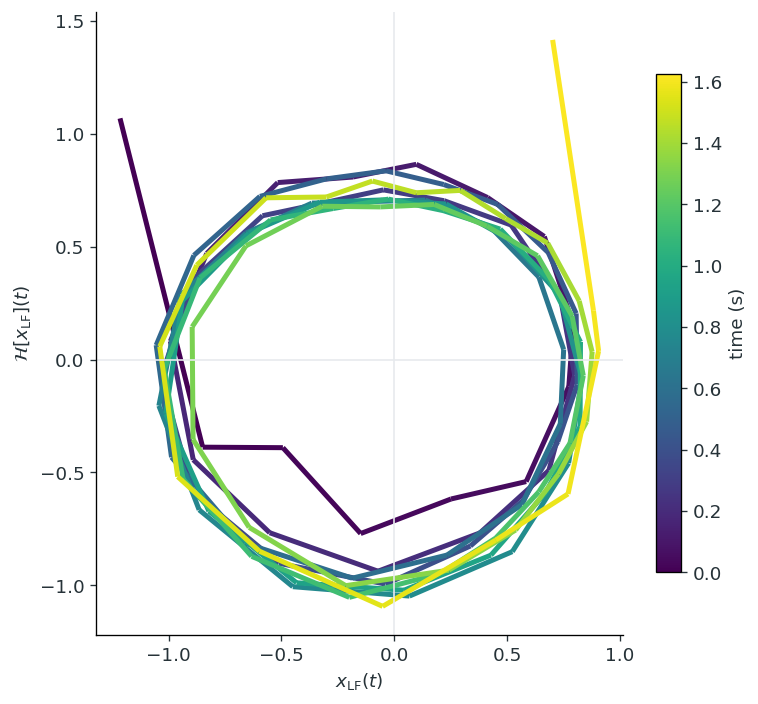

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 6))
line = colored_line(
    ax,
    mouse_centered["LF"],
    np.imag(mouse_analytic["LF"]),
    mouse_time,
    linewidth=3,
)
ax.axhline(0, color=LIGHT, lw=1)
ax.axvline(0, color=LIGHT, lw=1)
ax.set(
    xlabel=r"$x_{\rm LF}(t)$",
    ylabel=r"$\mathcal{H}[x_{\rm LF}](t)$",
)
ax.set_aspect("equal", adjustable="box")
fig.colorbar(line, ax=ax, label="time (s)", shrink=0.8)
fig.tight_layout()
plt.show()

### Phase from $\operatorname{atan2}$

To take the inverse tangent computationally, we will use $\operatorname{atan2}$ which returns the phase within each cycle between $-\pi$ and $\pi$:

$$
\theta_i(t)
=\operatorname{atan2}\!\left(\mathcal H[x_i](t),x_i(t)\right).
$$

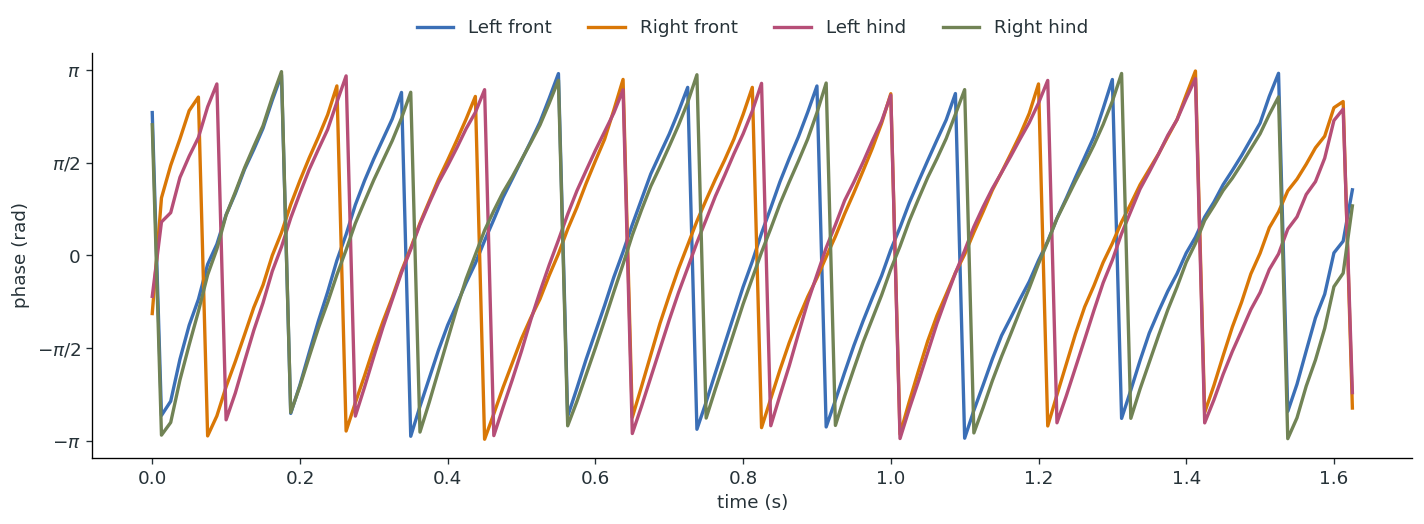

In [18]:
mouse_wrapped_phase = {
    limb: np.arctan2(
        np.imag(mouse_analytic[limb]), mouse_centered[limb]
    )
    for limb in limbs
}

fig, ax = plt.subplots(figsize=(12, 4.5))
for limb in limbs:
    ax.plot(
        mouse_time, mouse_wrapped_phase[limb],
        color=LIMB_COLORS[limb], lw=2, label=paw_names[limb],
    )
ax.set(
    xlabel="time (s)",
    ylabel="phase (rad)",
    yticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
    yticklabels=[r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"],
)
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02),
    ncol=4, frameon=False, borderaxespad=0,
)
fig.tight_layout()
plt.show()

This is hard to read, and the discontinuities will be a problem for further analysis.

We will *unwrap* the atan2 phases so that the phases keep increasing rather than jumping to $- \pi$.


*(A word of caution: this only works when the phase changes by less than half a cycle from one frame to the next.)*


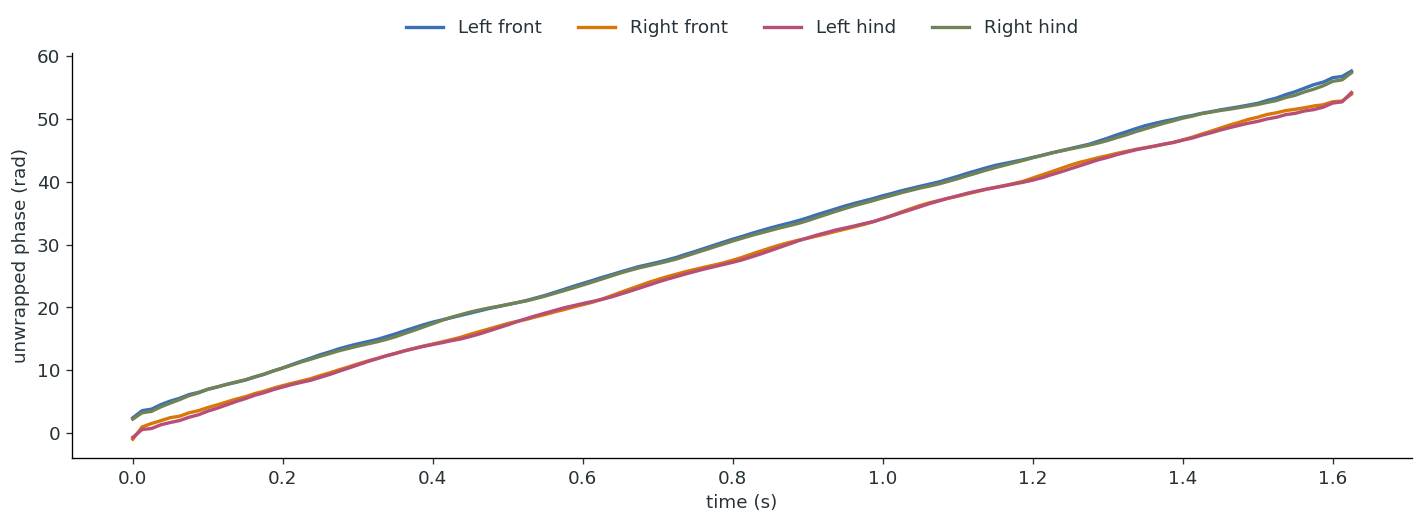

In [19]:
mouse_hilbert_phase = {
    limb: np.unwrap(mouse_wrapped_phase[limb])
    for limb in limbs
}

fig, ax = plt.subplots(figsize=(12, 4.5))
for limb in limbs:
    ax.plot(
        mouse_time, mouse_hilbert_phase[limb],
        color=LIMB_COLORS[limb], lw=2, label=paw_names[limb],
    )
ax.set(
    xlabel="time (s)",
    ylabel="unwrapped phase (rad)",
)
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02),
    ncol=4, frameon=False, borderaxespad=0,
)
fig.tight_layout()
plt.show()

### Problems with using the Hilbert transform

The Hilbert Transform only gives you the true phase for pure sine waves.

There are several ways to try to correct for this, none of which are perfect.

*My group has designed an RNN-based phase estimator which is much better. Ask me for more info later if you are interested...*

## Quantifying locomotion gait

The four limb phases for the mouse represent **three** independent differences which define the *gait*. Using Left-Front (LF) as the reference:

$$
\phi_{\mathrm{LF},j}(t)
=\theta_j(t)-\theta_{\mathrm{LF}}(t),
\qquad
j\in\{\mathrm{RF},\mathrm{LH},\mathrm{RH}\}.
$$

### Each gait is a different point in the relative-phase space

$$
\boldsymbol\phi=(\phi_{12},\phi_{13},\phi_{14})=(\phi_{\mathrm{LF,RF}},\phi_{\mathrm{LF,LH}},\phi_{\mathrm{LF,RH}}).
$$

| Pattern | Paws moving together | $\boldsymbol\phi$ |
| --- | --- | --- |
| Trot | Diagonal pairs | $(\pi,\pi,0)$ |
| Pace | Left pair; right pair | $(\pi,0,\pi)$ |
| Bound | Fore pair; hind pair | $(0,\pi,\pi)$ |
| Pronk | All four | $(0,0,0)$ |

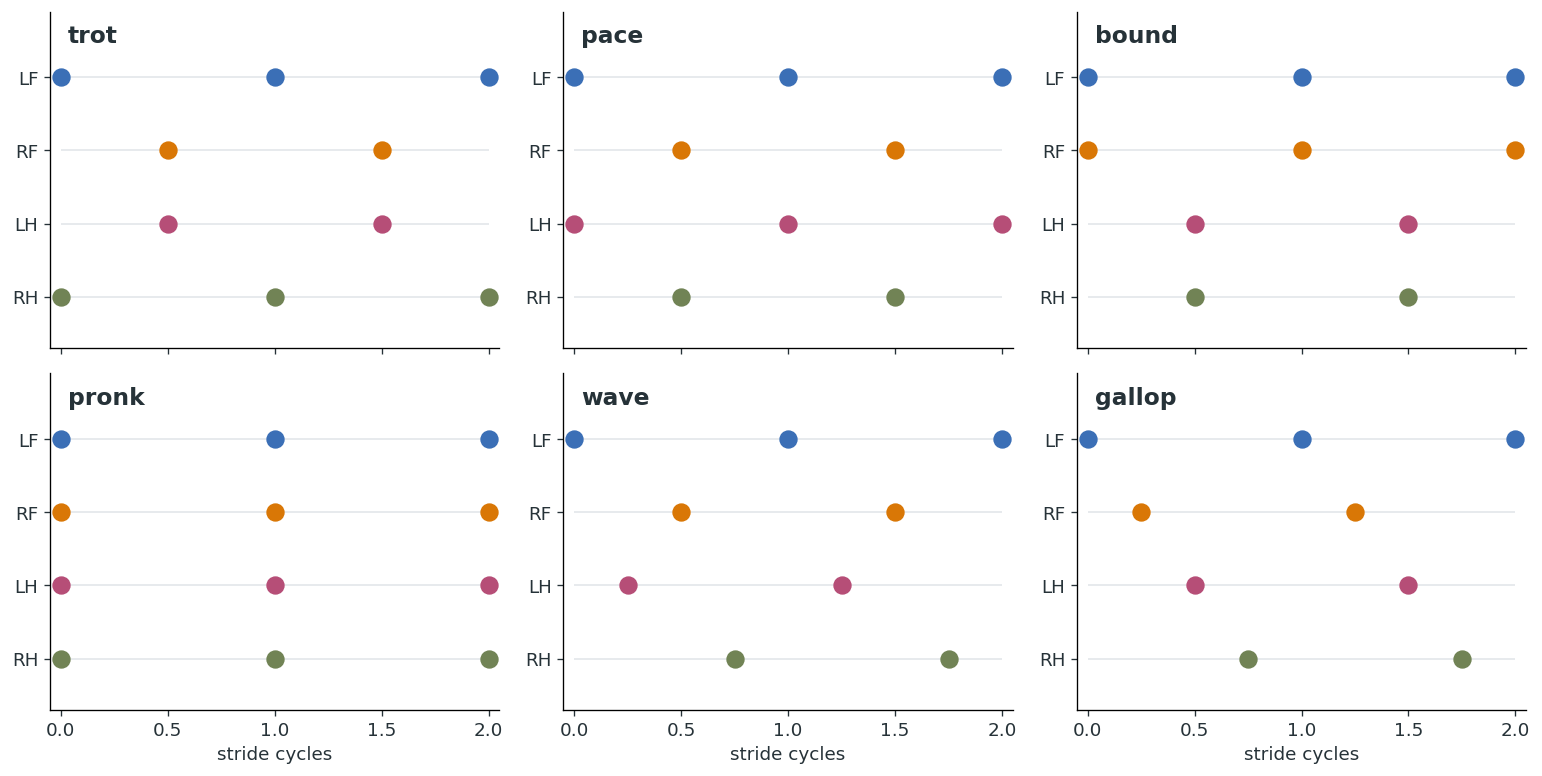

In [20]:
GAIT_LIMBS = PAW_ORDER.copy()
GAIT_STATES = {
    "trot": np.pi * np.array([0., 1., 1., 0.]),
    "pace": np.pi * np.array([0., 1., 0., 1.]),
    "bound": np.pi * np.array([0., 0., 1., 1.]),
}

# Mark one common phase event per stride; dots do not specify stance duration.
pattern_phases = {
    **GAIT_STATES,
    "pronk": np.zeros(4),
    "wave": np.pi * np.array([0., 1., 1.5, .5]),
    "gallop": np.pi * np.array([0., 1.5, 1., .5]),
}
fig, axes = plt.subplots(2, 3, figsize=(13, 6.6), sharex=True, sharey=True)
for ax, (name, theta) in zip(axes.flat, pattern_phases.items()):
    events = (-theta / TAU) % 1
    for row, (limb, event) in enumerate(zip(GAIT_LIMBS, events)):
        ax.hlines(row, 0, 2, color=LIGHT, lw=1.2)
        times = event + np.arange(3)
        ax.scatter(times[times <= 2], np.full(np.sum(times <= 2), row),
                   s=100, color=LIMB_COLORS[limb], zorder=3)
    ax.text(.04, .96, name, transform=ax.transAxes, va="top", fontsize=14, fontweight="bold")
    ax.set(xlim=(-.05, 2.05), ylim=(3.7, -.9), yticks=range(4), yticklabels=GAIT_LIMBS,
           xticks=[0, .5, 1, 1.5, 2])
    ax.tick_params(labelleft=True)
for ax in axes[-1]:
    ax.set_xlabel("stride cycles")
fig.tight_layout()
plt.show()

<table>
  <tr>
    <td align="center"><b>Trot</b><br><img src="../media/gait-trot.gif" width="360"></td>
    <td align="center"><b>Pace</b><br><img src="../media/gait-pace.gif" width="360"></td>
    <td align="center"><b>Gallop</b><br><img src="../media/gait-gallop.gif" width="360"></td>
  </tr>
</table>

> ## How many gaits do people have
> 
> Any volunteers for Prof. Cohen to record and analyze?

### What is the mouse gait?

For each of the 10 locomotion bouts in [`data/mouse/`](../data/mouse/), average the three phase differences over time:

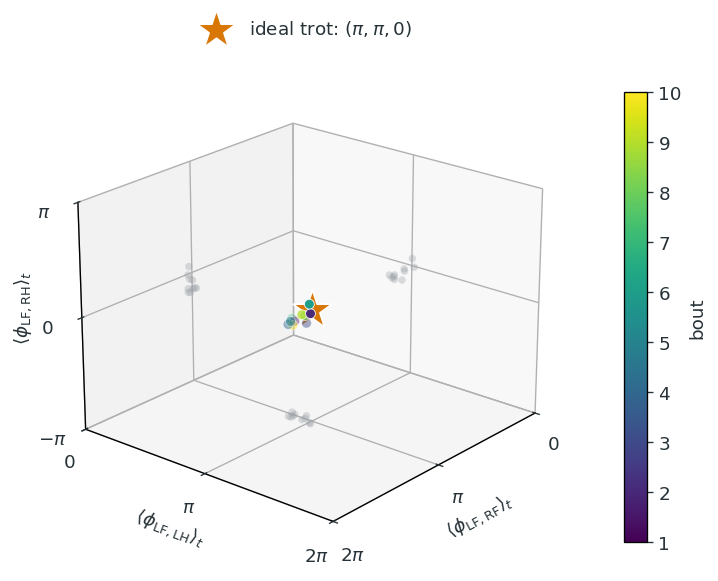

In [21]:
PHASE_EDGE_FRAMES = 10
phase_indices = np.arange(PHASE_EDGE_FRAMES, len(mouse) - PHASE_EDGE_FRAMES)
mouse_paths = sorted(MOUSE_DATA.glob("mouse-bout-*.csv"))
relative_limbs = limbs[1:]
ideal_trot = GAIT_STATES["trot"][1:]
bout_phase_means = []

for bout_number, path in enumerate(mouse_paths, start=1):
    bout = pd.read_csv(path)
    bout_phase = {}
    for limb in limbs:
        smoothed = savgol_filter(bout[limb].to_numpy(), 7, 2)
        centered = smoothed - np.mean(smoothed)
        quadrature = np.imag(hilbert(centered))
        bout_phase[limb] = np.unwrap(np.arctan2(quadrature, centered))

    bout_indices = np.arange(
        PHASE_EDGE_FRAMES, len(bout) - PHASE_EDGE_FRAMES
    )
    mean_differences = np.array([
        np.mean(
            bout_phase[limb][bout_indices]
            - bout_phase["LF"][bout_indices]
        )
        for limb in relative_limbs
    ])
    # Select the equivalent 2π branch nearest the ideal trot.
    mean_differences += TAU * np.round(
        (ideal_trot - mean_differences) / TAU
    )
    bout_phase_means.append([bout_number, *mean_differences])

bout_phase_means = pd.DataFrame(
    bout_phase_means, columns=["bout", *relative_limbs]
)

fig = plt.figure(figsize=(8, 6.5))
ax = fig.add_subplot(111, projection="3d")

# Orthogonal projections make the three pairwise phase views visible at once.
rf = bout_phase_means["RF"]
rh = bout_phase_means["RH"]
lh = bout_phase_means["LH"]
projection_style = dict(color=GREY, s=20, alpha=0.35, edgecolor="none", depthshade=False)
ax.scatter(np.zeros_like(rf), lh, rh, **projection_style)
ax.scatter(rf, np.zeros_like(lh), rh, **projection_style)
ax.scatter(rf, lh, np.full_like(rh, -np.pi), **projection_style)
points = ax.scatter(
    bout_phase_means["RF"],
    bout_phase_means["LH"],
    bout_phase_means["RH"],
    c=bout_phase_means["bout"], cmap="viridis",
    s=35, edgecolor="white", linewidth=0.5,
)
ax.scatter(
    *ideal_trot, marker="*", s=600, color=ORANGE,
    edgecolor="white", label=r"ideal trot: $(\pi,\pi,0)$",
)
ax.set(
    xlabel=r"$\langle\phi_{\rm LF,RF}\rangle_t$",
    ylabel=r"$\langle\phi_{\rm LF,LH}\rangle_t$",
    zlabel=r"$\langle\phi_{\rm LF,RH}\rangle_t$",
    xlim=(0, TAU), ylim=(0, TAU), zlim=(-np.pi, np.pi),
    xticks=[0, np.pi, TAU],
    yticks=[0, np.pi, TAU],
    zticks=[-np.pi, 0, np.pi],
    xticklabels=["0", r"$\pi$", r"$2\pi$"],
    yticklabels=["0", r"$\pi$", r"$2\pi$"],
    zticklabels=[r"$-\pi$", "0", r"$\pi$"],
)
ax.set_zlabel("")
ax.text2D(-.06, .52, r"$\langle\phi_{\rm LF,RH}\rangle_t$", transform=ax.transAxes,
          rotation=90, ha="center", va="center")
ax.view_init(elev=22, azim=40)
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False,
)
fig.colorbar(
    points, ax=ax, label="bout", ticks=range(1, 11),
    pad=0.10, shrink=0.75,
)
fig.subplots_adjust(left=0.12, right=0.82)
plt.show()

The gait is nearly an ideal trot, which has phase offsets $(\pi,\pi,0)$.

- diagonal paws move together (in phase)
- opposite diagonals alternate (out of phase).

## Quantifying synchronization

We define a *phase-locking value* (ranging from 0 to 1), that measures how constant the phase differences are over time:

$$
\mathrm{PLV}_{ij}
=\left|
\left\langle e^{i\phi_{ij}(t)}\right\rangle_t
\right|.
$$

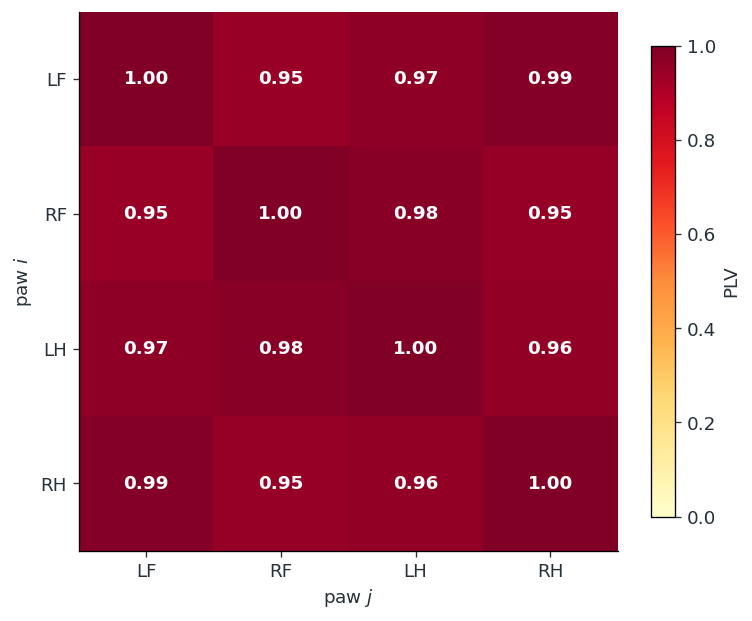

In [22]:
plv_matrix = np.eye(len(limbs))
for i, limb_i in enumerate(limbs):
    for j, limb_j in enumerate(limbs):
        phase_difference = (
            mouse_hilbert_phase[limb_j][phase_indices]
            - mouse_hilbert_phase[limb_i][phase_indices]
        )
        plv_matrix[i, j] = np.abs(np.mean(np.exp(1j * phase_difference)))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
image = ax.imshow(plv_matrix, cmap="YlOrRd", vmin=0, vmax=1)
for i in range(len(limbs)):
    for j in range(len(limbs)):
        ax.text(
            j, i, f"{plv_matrix[i, j]:.2f}",
            ha="center", va="center",
            color="white" if plv_matrix[i, j] > 0.72 else INK,
            fontweight="bold",
        )
ax.set(
    xticks=range(len(limbs)), yticks=range(len(limbs)),
    xticklabels=limbs, yticklabels=limbs,
    xlabel="paw $j$", ylabel="paw $i$",
)
fig.colorbar(image, ax=ax, label="PLV", shrink=0.82)
fig.tight_layout()
plt.show()

### Fit phase dynamics, not only phase order

With these phases, we can directly fit a phase-coupling (Generalized Kuramoto) model:

$$
\frac{d\theta_i}{dt}
=\omega
+\sum_{j\ne i}\alpha_{ij}
\sin\!\left(
\theta_i
-\theta_j
-\psi_{ij}
\right)
$$

$\alpha_{ij}$ is the coupling from paw $j$ to paw $i$, and $\psi_{ij}$ is the phase offset (gait). 

To fit this model with linear least squares, we can rewrite the interaction terms as:

$$
\alpha_{ij}\sin(\theta_i-\theta_j-\psi_{ij})
=a_{ij}\sin(\theta_i-\theta_j)
+b_{ij}\cos(\theta_i-\theta_j),
$$

where $a_{ij}=\alpha_{ij}\cos\psi_{ij}$ and $b_{ij}=-\alpha_{ij}\sin\psi_{ij}$. 

In [23]:
FIT_EDGE_FRAMES = 10
PHASE_DERIVATIVE_WINDOW = 11
PHASE_DERIVATIVE_ORDER = 3

fit_phase_chunks = []
fit_velocity_chunks = []
fit_bout_chunks = []

for bout_number, path in enumerate(mouse_paths, start=1):
    bout = pd.read_csv(path)
    bout_phase = []

    for limb in limbs:
        smoothed = savgol_filter(bout[limb].to_numpy(), 7, 2)
        centered = smoothed - np.mean(smoothed)
        bout_phase.append(
            np.unwrap(np.angle(hilbert(centered)))
        )

    bout_phase = np.column_stack(bout_phase)
    bout_velocity = savgol_filter(
        bout_phase,
        PHASE_DERIVATIVE_WINDOW,
        PHASE_DERIVATIVE_ORDER,
        deriv=1,
        delta=1 / MOUSE_FPS,
        axis=0,
    )
    interior = np.arange(
        FIT_EDGE_FRAMES, len(bout) - FIT_EDGE_FRAMES
    )
    fit_phase_chunks.append(bout_phase[interior])
    fit_velocity_chunks.append(bout_velocity[interior])
    fit_bout_chunks.append(
        np.full(interior.size, bout_number, dtype=int)
    )

fit_phase = np.vstack(fit_phase_chunks)
fit_velocity = np.vstack(fit_velocity_chunks)
fit_bout = np.concatenate(fit_bout_chunks)

n_limbs = len(limbs)
n_samples = len(fit_phase)
n_sources = n_limbs - 1
alpha = np.full((n_limbs, n_limbs), np.nan)
psi = np.full((n_limbs, n_limbs), np.nan)
predicted_velocity = np.zeros_like(fit_velocity)
fit_r_squared = np.zeros(n_limbs)

# Fit all paws together, with one shared stride frequency and directed interactions.
n_parameters = 1 + 2 * n_limbs * n_sources
design = np.zeros((n_limbs * n_samples, n_parameters))
response = fit_velocity.T.reshape(-1)
for i in range(n_limbs):
    rows = slice(i * n_samples, (i + 1) * n_samples)
    source_indices = [j for j in range(n_limbs) if j != i]
    phase_differences = fit_phase[:, [i]] - fit_phase[:, source_indices]
    start = 1 + i * 2 * n_sources
    design[rows, 0] = 1
    design[rows, start:start + n_sources] = np.sin(phase_differences)
    design[rows, start + n_sources:start + 2 * n_sources] = np.cos(phase_differences)

coefficients, _, rank, _ = np.linalg.lstsq(design, response, rcond=None)
if rank != design.shape[1]:
    raise RuntimeError("Rank-deficient shared-frequency fit")

omega = coefficients[0]
fit_condition_number = np.linalg.cond(design)
for i in range(n_limbs):
    source_indices = [j for j in range(n_limbs) if j != i]
    start = 1 + i * 2 * n_sources
    sine_coefficients = coefficients[start:start + n_sources]
    cosine_coefficients = coefficients[start + n_sources:start + 2 * n_sources]
    phase_differences = fit_phase[:, [i]] - fit_phase[:, source_indices]
    predicted_velocity[:, i] = (
        omega
        + np.sin(phase_differences) @ sine_coefficients
        + np.cos(phase_differences) @ cosine_coefficients
    )
    residual_sum_squares = np.sum(
        (fit_velocity[:, i] - predicted_velocity[:, i]) ** 2
    )
    total_sum_squares = np.sum(
        (fit_velocity[:, i] - np.mean(fit_velocity[:, i])) ** 2
    )
    fit_r_squared[i] = 1 - residual_sum_squares / total_sum_squares
    for coefficient_index, j in enumerate(source_indices):
        alpha[i, j] = np.hypot(
            sine_coefficients[coefficient_index],
            cosine_coefficients[coefficient_index],
        )
        psi[i, j] = np.arctan2(
            -cosine_coefficients[coefficient_index],
            sine_coefficients[coefficient_index],
        )

reconstructed_velocity = np.full_like(fit_velocity, omega)
for i in range(n_limbs):
    for j in range(n_limbs):
        if i != j:
            reconstructed_velocity[:, i] += alpha[i, j] * np.sin(
                fit_phase[:, i] - fit_phase[:, j] - psi[i, j]
            )
assert np.allclose(reconstructed_velocity, predicted_velocity)

print(
    f"Fit {n_limbs} equations to {n_samples:,} time points "
    f"from {len(mouse_paths)} bouts."
)
print(
    f"Shared fitted frequency: {omega:.2f} rad/s "
)


Fit 4 equations to 1,771 time points from 10 bouts.
Shared fitted frequency: 18.17 rad/s 


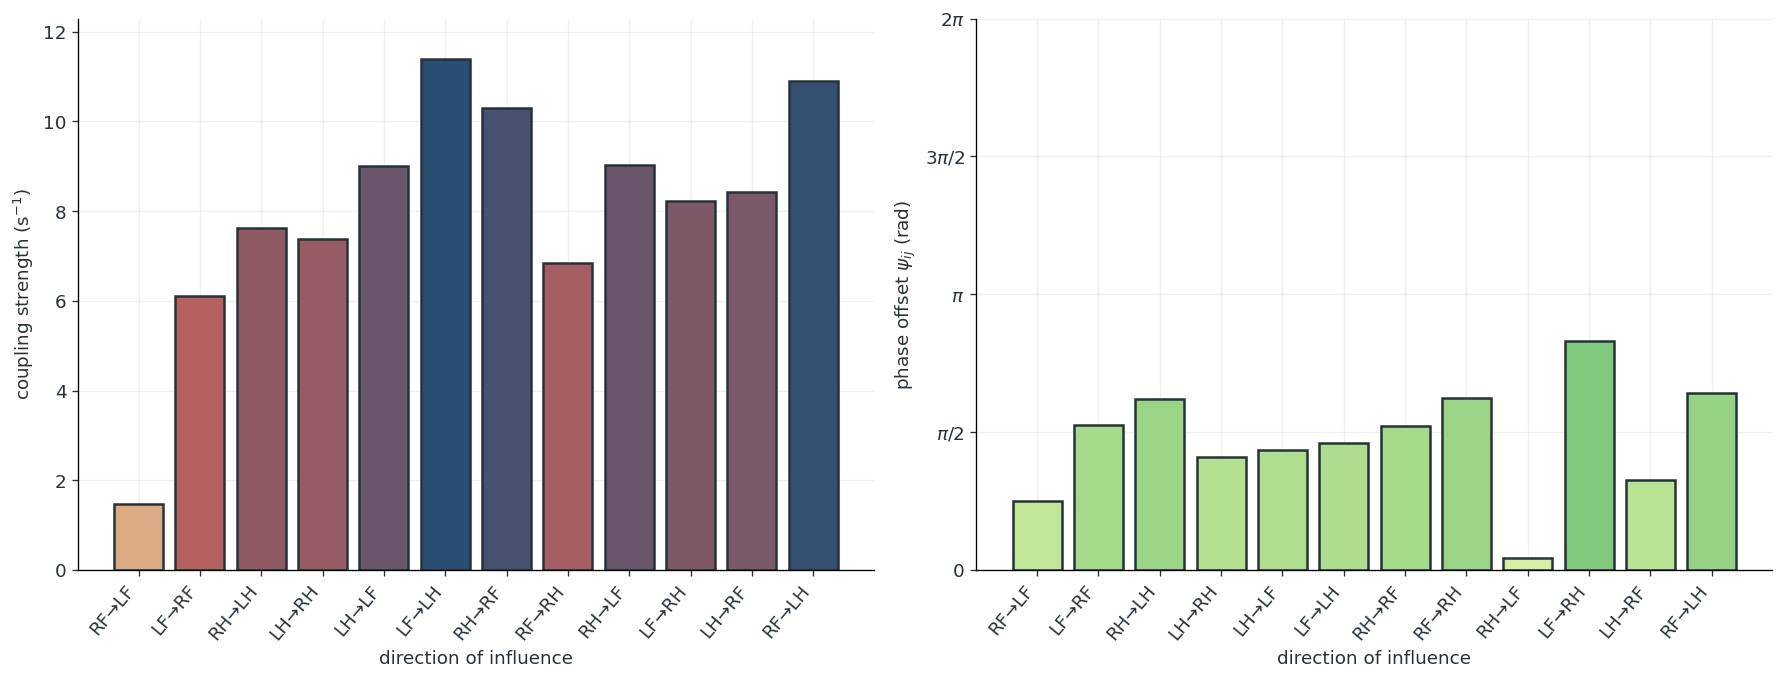

In [24]:
# One shared order: left–right, same-side, then diagonal pairs.
# Pair ij denotes influence j→i; paw order is LF, RF, LH, RH.
pair_numbers = ["12", "21", "34", "43", "13", "31",
                "24", "42", "14", "41", "23", "32"]
pair_order = [(int(pair[0]) - 1, int(pair[1]) - 1) for pair in pair_numbers]
pair_labels = [f"{limbs[j]}→{limbs[i]}" for i, j in pair_order]
coupling_strengths = np.array([alpha[i, j] for i, j in pair_order])
phase_offsets = np.array([psi[i, j] % TAU for i, j in pair_order])
alpha_cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "alpha_strength",
    [(0.0, "#E8C18F"), (0.55, "#B45F5F"), (1.0, "#294E73")],
)
alpha_norm = plt.Normalize(0, np.max(coupling_strengths))
alpha_colors = alpha_cmap(alpha_norm(coupling_strengths))

psi_norm = plt.Normalize(0, TAU)
psi_colors = plt.colormaps["YlGn"](
    0.25 + 0.55 * psi_norm(phase_offsets)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
axes[0].bar(
    pair_labels, coupling_strengths,
    color=alpha_colors, edgecolor=INK, linewidth=1.5,
)
axes[0].set(
    xlabel="direction of influence",
    ylabel=r"coupling strength (s$^{-1}$)",
    ylim=(0, 1.08 * np.max(coupling_strengths)),
)

axes[1].bar(
    pair_labels, phase_offsets,
    color=psi_colors, edgecolor=INK, linewidth=1.5,
)
axes[1].set(
    xlabel="direction of influence",
    ylabel=r"phase offset $\psi_{ij}$ (rad)",
    ylim=(0, TAU),
    yticks=[0, np.pi / 2, np.pi, 3 * np.pi / 2, TAU],
    yticklabels=["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"],
)

for ax in axes:
    ax.tick_params(axis="x", rotation=50)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
    ax.grid(alpha=0.18)
    ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

... but unfortunately that is a very small amount of data and our fit only explains 15% of the data.

To do this properly, we use 30,000 bouts containing >2 million data points.


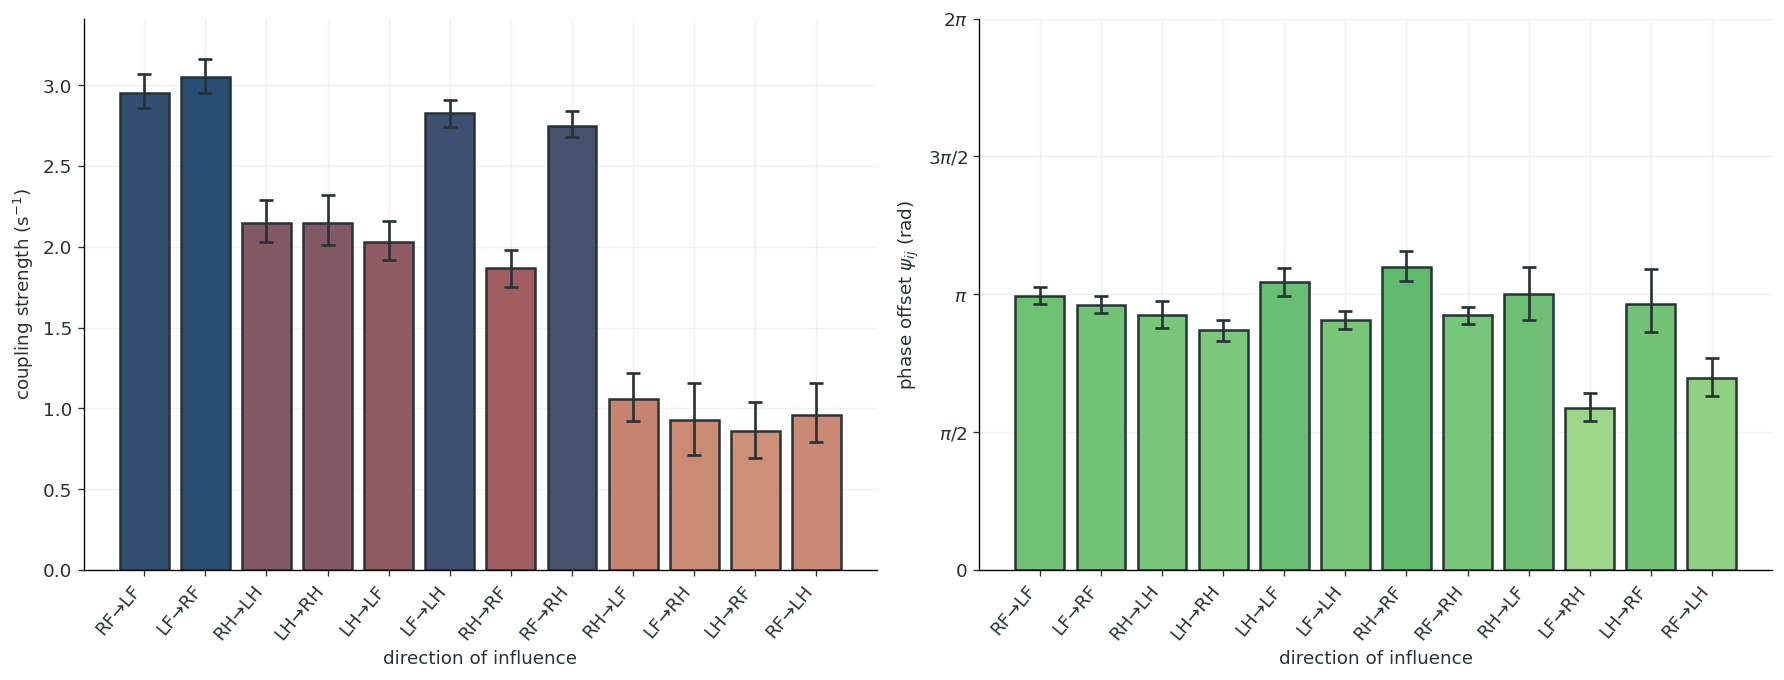

In [25]:
# Approximate values digitized from the instructor-supplied fit figures.
# Preserve the original lower/upper error-bar endpoints; their interval type is unspecified.
full_fit = pd.read_csv(MOUSE_DATA / "mouse-full-fit-digitized.csv").set_index(["receiver", "source"])
full_fit = full_fit.loc[[(limbs[i], limbs[j]) for i, j in pair_order]]
full_strength = full_fit["coupling"].to_numpy()
full_offset = full_fit["phase_offset"].to_numpy()
strength_error = np.vstack([
    full_strength - full_fit["coupling_lower"].to_numpy(),
    full_fit["coupling_upper"].to_numpy() - full_strength,
])
offset_error = np.vstack([
    full_offset - full_fit["phase_offset_lower"].to_numpy(),
    full_fit["phase_offset_upper"].to_numpy() - full_offset,
])
assert np.all(strength_error >= 0) and np.all(offset_error >= 0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
error_style = dict(ecolor=INK, elinewidth=1.6, capsize=4, capthick=1.6)
axes[0].bar(pair_labels, full_strength, yerr=strength_error,
            color=alpha_cmap(plt.Normalize(0, full_strength.max())(full_strength)),
            edgecolor=INK, linewidth=1.5, error_kw=error_style)
axes[1].bar(pair_labels, full_offset, yerr=offset_error,
            color=plt.colormaps["YlGn"](.25 + .55 * psi_norm(full_offset)),
            edgecolor=INK, linewidth=1.5, error_kw=error_style)
axes[0].set(ylabel=r"coupling strength (s$^{-1}$)",
            ylim=(0, 1.08 * full_fit["coupling_upper"].max()))
axes[1].set(ylabel=r"phase offset $\psi_{ij}$ (rad)", ylim=(0, TAU),
            yticks=[0, np.pi / 2, np.pi, 3 * np.pi / 2, TAU],
            yticklabels=["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
for ax in axes:
    ax.tick_params(axis="x", rotation=50)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
    ax.set_xlabel("direction of influence")
    ax.grid(alpha=.18)
    ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


## Gait frustration

The fitted phase preferences suggest **frustration**: diagonal paws move together, even though their effective interaction tends to pull them apart in phase.

A stable *phase-locked* system does not mean every pair's preferred timing is satisfied.

### Three pairs cannot all be half a cycle apart

Take any three paws. Their physical relative phases must close around the loop:

$$
\phi_{ij}+\phi_{jk}+\phi_{ki}=0\pmod{2\pi}.
$$

Three antiphase preferences would require $\pi+\pi+\pi=0\pmod{2\pi}$.

At least one preference must be compromised. This is **frustration**.

### Simplified model of frustrated locomotion

Let's build a simple model of mouse locomotion that let's us explore how it works. We will assume all paws want to be out of phase with all other paws:

$$
\dot\theta_i=\omega+b\sum_{j\ne i}A_{ij}\sin(\theta_j-\theta_i-\pi).
$$


We will also assume all paws have the same natural frequency and that the couplings are reciprocal: $A_{ij}=A_{ji}$

### Reduce coupling to three parameters

| Pair type | Paw pairs | Coupling $bA_{ij}$ |
| --- | --- | --- |
| Diagonal | LF–RH, RF–LH | $b$ |
| Left–right | LF–RF, LH–RH | $b\alpha_c$ |
| Same-side fore–hind | LF–LH, RF–RH | $b\alpha_h$ |

- $\alpha_c$: **contralateral** (left–right)
- $\alpha_h$: **homolateral** (same-side fore–hind)


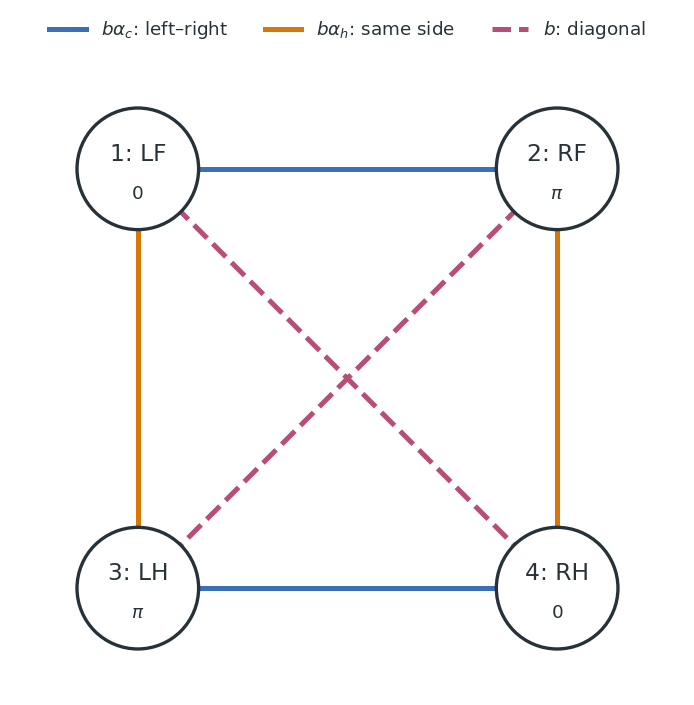

In [26]:
from scipy.integrate import solve_ivp
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

# All new simulations use b = 1 and remove the common rotation omega*t.
# Thus plotted simulation time is bt. This is an illustrative symmetric
# model, not a refit or a numerical reduction of the directed fit above.
GAIT_COLORS = {"trot": BLUE, "pace": ORANGE, "bound": PINK}
def gait_matrix(alpha_c, alpha_h):
    return np.array([
        [0., alpha_c, alpha_h, 1.],
        [alpha_c, 0., 1., alpha_h],
        [alpha_h, 1., 0., alpha_c],
        [1., alpha_h, alpha_c, 0.],
    ])

def gait_rhs(t, theta, alpha_c, alpha_h, detuning=None):
    # sin(theta_j - theta_i - pi) = sin(theta_i - theta_j).
    difference = theta[:, None] - theta[None, :]
    velocity = (gait_matrix(alpha_c, alpha_h) * np.sin(difference)).sum(axis=1)
    return velocity if detuning is None else velocity + np.asarray(detuning)

def gait_potential(theta, alpha_c, alpha_h):
    difference = theta[..., :, None] - theta[..., None, :]
    return 0.5 * np.sum(gait_matrix(alpha_c, alpha_h) * np.cos(difference), axis=(-2, -1))

def gait_jacobian(theta, alpha_c, alpha_h):
    offdiag = -gait_matrix(alpha_c, alpha_h) * np.cos(theta[:, None] - theta[None, :])
    np.fill_diagonal(offdiag, -offdiag.sum(axis=1))
    return offdiag

def gait_path(q, channel):
    q = np.asarray(q)
    zero = np.zeros_like(q)
    if channel == "h":
        return np.stack([zero, zero + np.pi, np.pi + q, q], axis=-1)
    return np.stack([zero, np.pi + q, zero + np.pi, q], axis=-1)

positions = np.array([[-1., 1.], [1., 1.], [-1., -1.], [1., -1.]])
fig, ax = plt.subplots(figsize=(8.5, 6))
for pairs, color, label, style in [
    ([(0, 1), (2, 3)], BLUE, r"$b\alpha_c$: left–right", "-"),
    ([(0, 2), (1, 3)], ORANGE, r"$b\alpha_h$: same side", "-"),
    ([(0, 3), (1, 2)], PINK, r"$b$: diagonal", "--"),
]:
    for edge_number, (i, j) in enumerate(pairs):
        ax.plot(*positions[[i, j]].T, color=color, lw=3, ls=style,
                label=label if edge_number == 0 else None, zorder=1)
for limb, (x, y), phase in zip(GAIT_LIMBS, positions, GAIT_STATES["trot"]):
    ax.add_patch(Circle((x, y), .29, facecolor="white", edgecolor=INK, lw=2, zorder=3))
    ax.text(x, y + .07, f"{PAW_INDEX[limb] + 1}: {limb}", ha="center", va="center", fontsize=14, zorder=4)
    ax.text(x, y - .12, "0" if phase == 0 else r"$\pi$", ha="center", va="center", zorder=4)
ax.set(xlim=(-1.6, 1.6), ylim=(-1.5, 1.5), aspect="equal")
ax.axis("off")
ax.legend(loc="lower center", bbox_to_anchor=(.5, 1.01), ncol=3, frameon=False)
fig.tight_layout()
plt.show()

### Gait perturbations

Shift away from trot by an angle $\delta$ in two ways:

- Shift both *hind paws* forward relative to the fore paws:

$$
\boldsymbol\phi_{\mathrm{hind\text{-}fore}}(\delta)=(\pi,\pi+\delta,\delta).
$$

- Shift both *right paws* forward relative to the left paws:

$$
\boldsymbol\phi_{\mathrm{right\text{-}left}}(\delta)=(\pi+\delta,\pi,\delta).
$$

| Shifted Paws | $\delta=\pi/2$ | $\delta=\pi$ |
| --- | --- | --- |
| Hind paws | Wave | Pace |
| Right paws | Gallop | Bound |


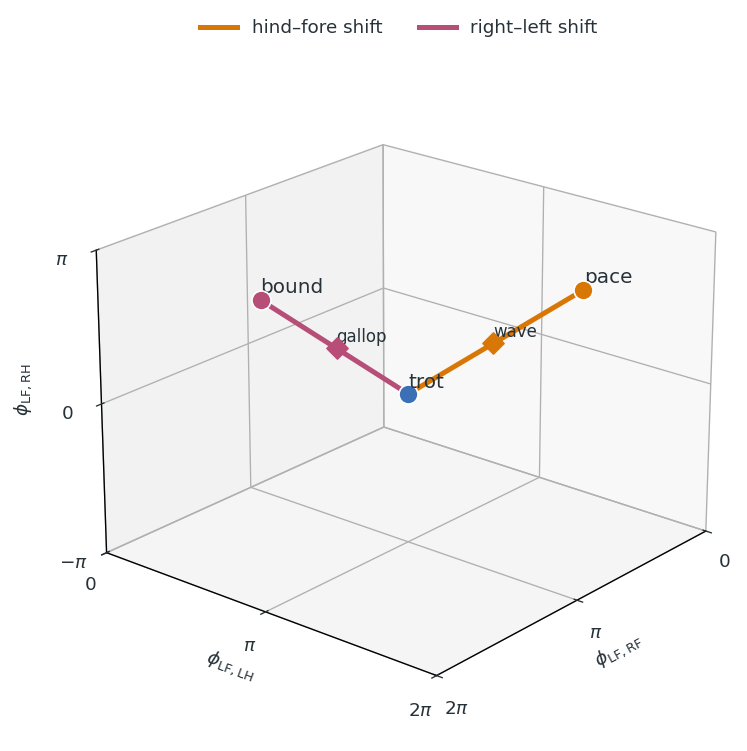

In [27]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
q_values = np.linspace(0, np.pi, 201)
for channel, color, label in [("h", ORANGE, "hind–fore shift"), ("c", PINK, "right–left shift")]:
    path = gait_path(q_values, channel)[:, 1:]
    ax.plot(*path.T, color=color, lw=3, label=label)
    middle = gait_path(np.pi / 2, channel)[1:]
    ax.scatter(*middle, s=80, color=color, marker="D")
    ax.text(*(middle + np.array([.12, .10, .22])), "wave" if channel == "h" else "gallop", fontsize=10)
for name, point in [
    ("trot", GAIT_STATES["trot"][1:]),
    ("pace", gait_path(np.pi, "h")[1:]),
    ("bound", gait_path(np.pi, "c")[1:]),
]:
    ax.scatter(*point, s=130, color=GAIT_COLORS[name], edgecolor="white", zorder=5)
    ax.text(*(np.array(point) + [.12, .10, .22]), name, fontsize=12)
ax.set(
    xlabel=r"$\phi_{\rm LF,RF}$",
    ylabel=r"$\phi_{\rm LF,LH}$",
    zlabel=r"$\phi_{\rm LF,RH}$",
    xlim=(0, TAU), ylim=(0, TAU), zlim=(-np.pi, np.pi),
    xticks=[0, np.pi, TAU], yticks=[0, np.pi, TAU], zticks=[-np.pi, 0, np.pi],
    xticklabels=["0", r"$\pi$", r"$2\pi$"],
    yticklabels=["0", r"$\pi$", r"$2\pi$"],
    zticklabels=[r"$-\pi$", "0", r"$\pi$"],
)
ax.set_zlabel("")
ax.text2D(-.06, .52, r"$\phi_{\rm LF,RH}$", transform=ax.transAxes,
          rotation=90, ha="center", va="center")
ax.view_init(elev=22, azim=40)
ax.legend(loc="lower center", bbox_to_anchor=(.5, 1.02), ncol=2, frameon=False)
fig.subplots_adjust(left=.04, right=.91, bottom=.08, top=.88)
plt.show()


### A four-paw gait can act like two oscillators

If we shift the hind paws by $\delta$ relative to the fore paws:

$$
\boldsymbol\phi_{\mathrm{hind\text{-}fore}}=(\pi,\pi+\delta,\delta).
$$

Along this path, the left–right pairs stay half a cycle apart, so their $\alpha_c$ terms are zero. At every time, the paw phases share an arbitrary stride phase $\Theta(t)$:

$$
(\theta_{\rm LF},\theta_{\rm RF},\theta_{\rm LH},\theta_{\rm RH})
=(\Theta,\Theta+\pi,\Theta+\pi+\delta,\Theta+\delta).
$$

The two fore paws advance together, and the two hind paws advance together. Substituting these phases into the four-paw model gives

$$
\dot\theta_{\rm LF}-\omega=\dot\theta_{\rm RF}-\omega
=b(\alpha_h-1)\sin\delta,
$$

$$
\dot\theta_{\rm LH}-\omega=\dot\theta_{\rm RH}-\omega
=b(1-\alpha_h)\sin\delta.
$$

The gait shift is $\delta=\theta_{\rm RH}-\theta_{\rm LF}$, so the common stride frequency cancels:

$$
\dot\delta
=\dot\theta_{\rm RH}-\dot\theta_{\rm LF}
=\boxed{-2b(\alpha_h-1)\sin\delta}.
$$

The stability of the possible gaits depends on the magnitude of $\alpha_h$:

- $\alpha_h>1$: same-side fore–hind interactions dominate. Small shifts return to the **trot** ($\delta=0$).
- $\alpha_h=1$: same-side and diagonal interactions balance exactly. Every shift between trot and pace is **neutral**.
- $\alpha_h<1$: diagonal interactions dominate. The trot is unstable and the gait moves toward **pace** ($\delta=\pi$).


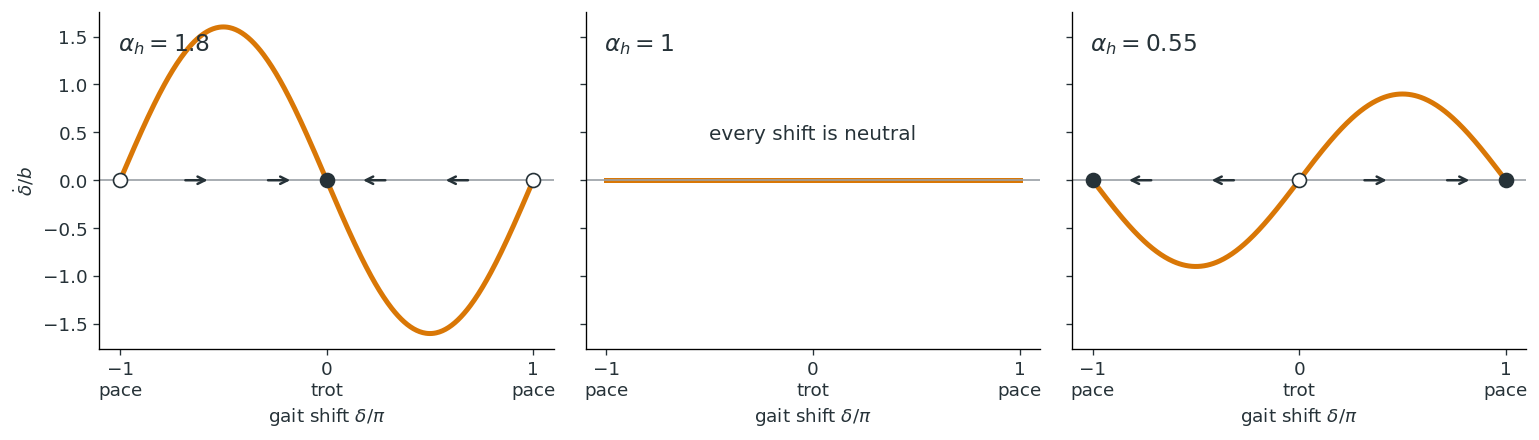

In [28]:
q_grid = np.linspace(-np.pi, np.pi, 401)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True, sharey=True)
for col, ah in enumerate([1.8, 1., .55]):
    flow = -2 * (ah - 1) * np.sin(q_grid)
    axes[col].plot(q_grid / np.pi, flow, lw=3, color=ORANGE)
    axes[col].text(.04, .94, rf"$\alpha_h={ah:g}$", transform=axes[col].transAxes,
                   va="top", fontsize=14)
    axes[col].axhline(0, color=GREY, lw=1)
    for q0 in ([] if ah == 1 else [-np.pi, 0., np.pi]):
        stable = (ah - 1) * np.cos(q0) > 0
        axes[col].scatter(q0 / np.pi, 0, s=70,
                          facecolor=INK if stable else "white", edgecolor=INK, zorder=4)
    if ah == 1:
        axes[col].text(.5, .62, "every shift is neutral",
                       transform=axes[col].transAxes, ha="center", fontsize=12)
    if ah != 1:
        for q0 in [-.7, -.3, .3, .7]:
            direction = np.sign(-2 * (ah - 1) * np.sin(np.pi * q0))
            axes[col].annotate("", xy=(q0 + .14 * direction, 0), xytext=(q0, 0),
                               arrowprops=dict(arrowstyle="->", color=INK, lw=1.5))
    axes[col].set(xlabel=r"gait shift $\delta/\pi$", xticks=[-1, 0, 1],
                  xticklabels=["−1\npace", "0\ntrot", "1\npace"])
axes[0].set_ylabel(r"$\dot\delta/b$")
fig.tight_layout()
plt.show()


### Test stability with the local slope

Shifting from the fixed point,  $\delta=\delta^*+\eta$, we find

$$
\dot\eta=\lambda\eta,\qquad
\lambda=\left.\frac{d\dot\delta}{d\delta}\right|_{\delta^*}
=-2b(\alpha_h-1)\cos\delta^*.
$$

At the trot, $\delta^*=0$. A hind–fore perturbation decays if $\alpha_h>1$.

There are three ways to change the relative timing:

| Perturbation from trot | Growth rate $\lambda$ |
| --- | --- |
| Advance hindlimbs relative to forelimbs | $-2b(\alpha_h-1)$ |
| Advance right limbs relative to left limbs | $-2b(\alpha_c-1)$ |
| Advance one diagonal pair relative to the other | $-2b(\alpha_c+\alpha_h)$ |

All three decay when $\alpha_h>1$ and $\alpha_c>1$. Advancing every paw equally changes stride phase, not gait.

### The same network can trot, pace, or bound

There are three stable gaits in this model:

| Stable gait | Stability conditions |
| --- | --- |
| Trot | $\alpha_h>1$ and $\alpha_c>1$ |
| Pace | $\alpha_h<1$ and $\alpha_c>\alpha_h$ |
| Bound | $\alpha_c<1$ and $\alpha_h>\alpha_c$ |

We can change gait by change the $\alpha$s.

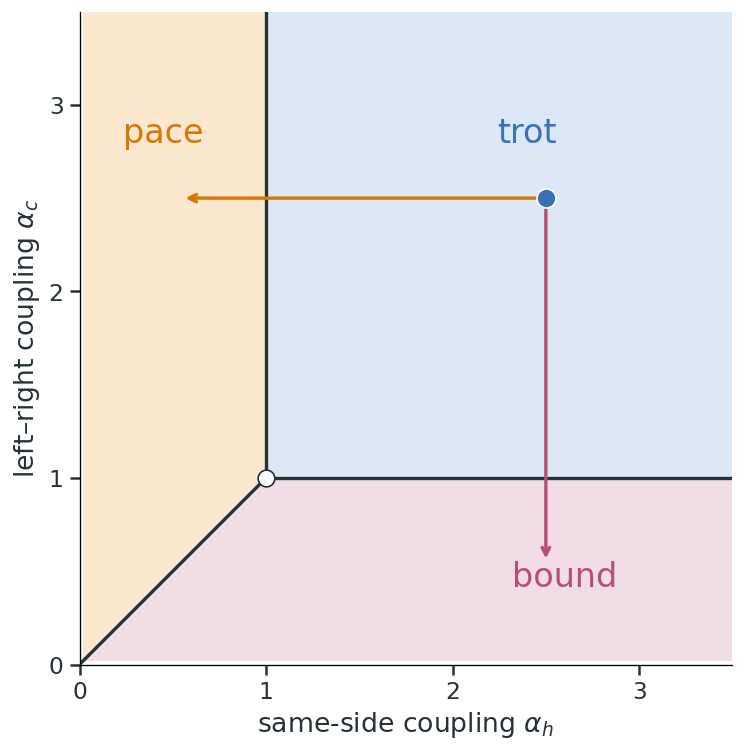

In [29]:
values = np.linspace(.02, 3.5, 501)
ah_grid, ac_grid = np.meshgrid(values, values)
# Which pair type is weakest: diagonal (1), same side (ah), or left–right (ac)?
regions = np.argmin(np.stack([np.ones_like(ah_grid), ah_grid, ac_grid]), axis=0)
fig, ax = plt.subplots(figsize=(8, 6.4))
ax.pcolormesh(ah_grid, ac_grid, regions, shading="auto",
              cmap=ListedColormap(["#DCE8F6", "#FBE8CE", "#F2DCE5"]), vmin=0, vmax=2)
ax.plot([1, 1], [1, 3.5], color=INK, lw=2)
ax.plot([1, 3.5], [1, 1], color=INK, lw=2)
ax.plot([0, 1], [0, 1], color=INK, lw=2)
for name, point in [("trot", (2.4, 2.8)), ("pace", (.45, 2.8)), ("bound", (2.6, .42))]:
    ax.text(*point, name, fontsize=20, color=GAIT_COLORS[name], ha="center")
ax.scatter(2.5, 2.5, s=130, color=BLUE, edgecolor="white", zorder=5)
ax.annotate("", xy=(.55, 2.5), xytext=(2.5, 2.5), arrowprops=dict(arrowstyle="->", lw=2, color=ORANGE))
ax.annotate("", xy=(2.5, .55), xytext=(2.5, 2.5), arrowprops=dict(arrowstyle="->", lw=2, color=PINK))
ax.scatter(1, 1, s=100, facecolor="white", edgecolor=INK, zorder=5)
ax.set(xlabel=r"same-side coupling $\alpha_h$", ylabel=r"left–right coupling $\alpha_c$",
       xlim=(0, 3.5), ylim=(0, 3.5), aspect="equal", xticks=[0, 1, 2, 3], yticks=[0, 1, 2, 3])
ax.xaxis.label.set_size(16)
ax.yaxis.label.set_size(16)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=14,   # tick-label font size
    length=6,       # tick length
    width=1.5       # tick thickness
)
fig.tight_layout()
plt.show()

### At the boundary, the restoring force vanishes

At $\alpha_h=1$ with $\alpha_c>1$,

$$
\dot\delta=0\quad\text{for every }\delta.
$$

Trot, pace, and the intervening wave patterns lie on a flat potential. Displacements along it remain; displacements away from it decay. The shift is *neutral*, not restored to one preferred value.

For $\alpha_h<1$, a small displacement from the trot grows toward a pace.

The right–left shift connects trot to bound in the same way at $\alpha_c=1$ with $\alpha_h>1$.

### Simulation of changing gait

We will near a trot (there needs to be some small offset to perturb...) and weaken the same-side or opposite side coupling:

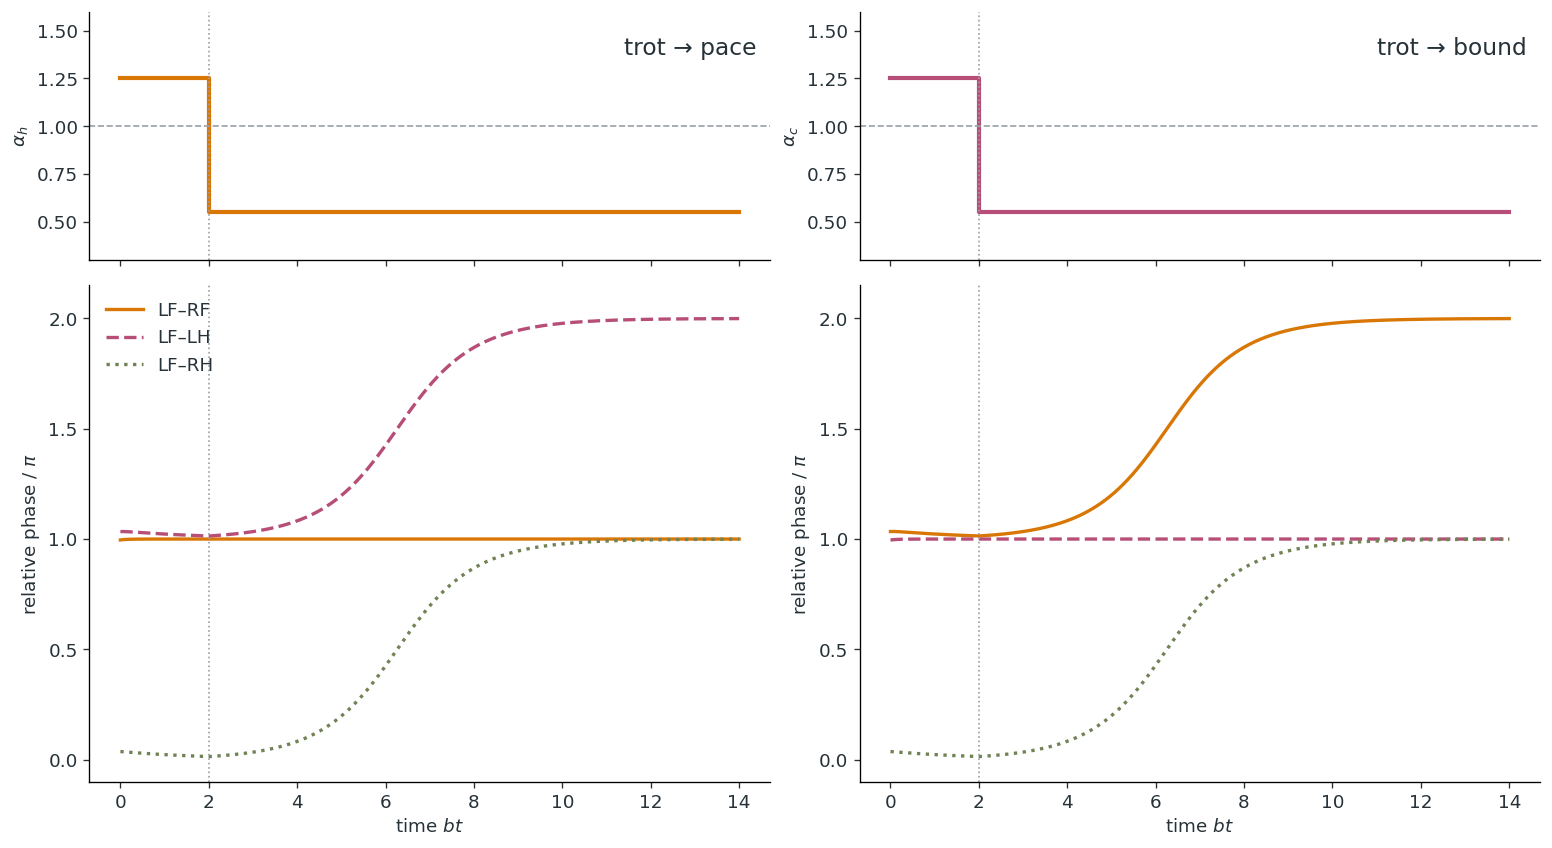

In [30]:
gait_switch_time = 2.
gait_times = np.linspace(0, 14, 1401)
gait_switch_solutions = {}
fig, axes = plt.subplots(2, 2, figsize=(13, 7.2), sharex="col", gridspec_kw={"height_ratios": [1, 2]})
for col, (channel, target) in enumerate([("h", "pace"), ("c", "bound")]):
    def changing_rhs(t, theta):
        changing = 1.25 if t < gait_switch_time else .55
        ac, ah = (2.5, changing) if channel == "h" else (changing, 2.5)
        return gait_rhs(t, theta, ac, ah)

    # Deterministic small perturbations both along and off the invariant path.
    initial = gait_path(.12, channel) + np.array([.008, -.005, -.006, .003])
    solution = solve_ivp(changing_rhs, (0, gait_times[-1]), initial,
                         t_eval=gait_times, rtol=1e-9, atol=1e-11, max_step=.03)
    assert solution.success
    relative = (solution.y[1:] - solution.y[[0]]) / np.pi
    gait_switch_solutions[channel] = solution
    axes[0, col].step([0, gait_switch_time, gait_times[-1]], [1.25, .55, .55],
                      where="post", color=GAIT_COLORS[target], lw=2.5)
    axes[0, col].axhline(1, color=GREY, ls="--", lw=1)
    axes[0, col].text(.98, .9, "trot → " + target, transform=axes[0, col].transAxes,
                      ha="right", va="top", fontsize=14)
    axes[0, col].set(ylabel=rf"$\alpha_{channel}$", ylim=(.3, 1.6))
    for row, limb in enumerate(GAIT_LIMBS[1:]):
        axes[1, col].plot(solution.t, relative[row], color=LIMB_COLORS[limb], lw=2,
                          label="LF–" + limb, ls=["-", "--", ":"][row])
    for ax in axes[:, col]:
        ax.axvline(gait_switch_time, color=GREY, ls=":", lw=1)
    axes[1, col].set(xlabel=r"time $bt$", ylabel=r"relative phase / $\pi$", yticks=[0, .5, 1, 1.5, 2], ylim=(-.1, 2.15))
axes[1, 0].legend(loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

### Recovery slows before the gait changes

Near a stable trot, $\delta^*=0$ and $\eta=\delta$. In Lecture 3 we found:

$$
\eta(t)=\eta_0e^{\lambda t}=\eta_0e^{-t/t_{\rm relax}},
\qquad
t_{\rm relax}=-\frac{1}{\lambda}
=\frac{1}{2b(\alpha_h-1)}.
$$

As $\alpha_h\to1^+$, recovery becomes slow even though the mean gait remains a trot. Perturbations grow until you lock in to the new gait.

### Frequency variation

What if the paws have different natural frequencies?

Let's try setting the hindlimb frequencies to $\omega_H$ and forelimb frequencies to $\omega_F$:

$$
\Delta\omega=\omega_H-\omega_F,
\qquad
\boxed{\dot\delta=\Delta\omega-2b(\alpha_h-1)\sin\delta.}
$$

For phase locking, we need:

$$
\dot\delta=0
\quad\Longrightarrow\quad
\sin\delta^*=\frac{\Delta\omega}{2b(\alpha_h-1)}.
$$

A stable locked gait exists when $|\Delta\omega|<2b|\alpha_h-1|$.

### A frequency difference can shift trot toward a wave

For $\alpha_h>1$, equal natural frequencies produce a trot: $\delta^*=0$.

If the hind paws have a higher natural frequency, they must move ahead relative to the fore paws for coupling to balance that difference:

$$
\delta^*=\sin^{-1}\left[\frac{\Delta\omega}{2b(\alpha_h-1)}\right].
$$

The paws still share one mean stride frequency, but their relative timing is *no longer a perfect trot*.

The largest frequency difference that coupling can balance is:

$$
|\Delta\omega|=2b(\alpha_h-1)
\quad\Longrightarrow\quad
|\delta^*|=\frac{\pi}{2}.
$$

The four paws are now spaced a quarter cycle apart which results in a **wave gait**. At the same time, recovery from a small perturbation also becomes slow:

$$
\lambda=-2b(\alpha_h-1)\cos\delta^*\to0.
$$

Beyond this limit, coupling cannot maintain a constant phase difference and you get **phase slips**.

A right–left natural-frequency difference gives the same progression toward a **gallop gait**.


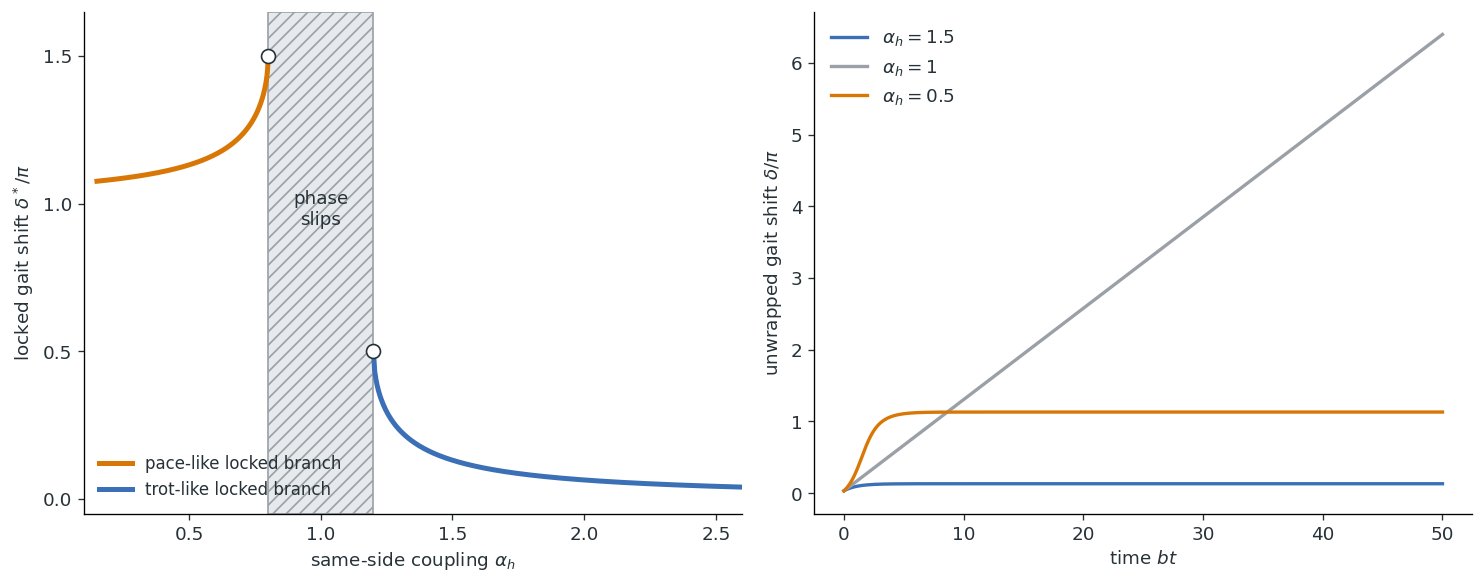

In [31]:
# ac=2.5 keeps the transverse directions stable on the locked branches shown.
# Delta omega / b = 0.4; boundaries are ah=0.8 and 1.2.
gait_detuning = .4
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
left = np.linspace(.15, .8 - 1e-5, 300)
right = np.linspace(1.2 + 1e-5, 2.6, 300)
q_pace = np.pi + np.arcsin(gait_detuning / (2 * (1 - left)))
q_trot = np.arcsin(gait_detuning / (2 * (right - 1)))
axes[0].plot(left, q_pace / np.pi, color=ORANGE, lw=3, label="pace-like locked branch")
axes[0].plot(right, q_trot / np.pi, color=BLUE, lw=3, label="trot-like locked branch")
axes[0].axvspan(.8, 1.2, facecolor=LIGHT, hatch="///", edgecolor=GREY)
axes[0].text(1., .98, "phase\nslips", ha="center", va="center")
axes[0].scatter([.8, 1.2], [1.5, .5], s=70, facecolor="white", edgecolor=INK, zorder=4)
axes[0].set(xlabel=r"same-side coupling $\alpha_h$", ylabel=r"locked gait shift $\delta^*/\pi$",
            xlim=(.1, 2.6), ylim=(-.05, 1.65), yticks=[0, .5, 1, 1.5])
axes[0].legend(frameon=False, loc="lower left", fontsize=10)
detuning_times = np.linspace(0, 50, 1001)
for ah, color in [(1.5, BLUE), (1., GREY), (.5, ORANGE)]:
    # Full system: fore=-Delta/2, hind=+Delta/2 in the mean rotating frame.
    sol = solve_ivp(lambda t, y: gait_rhs(t, y, 2.5, ah, [-.2, -.2, .2, .2]),
                    (0, detuning_times[-1]), gait_path(.1, "h"),
                    t_eval=detuning_times, rtol=1e-9, atol=1e-11, max_step=.1)
    axes[1].plot(sol.t, (sol.y[PAW_INDEX["RH"]] - sol.y[PAW_INDEX["LF"]]) / np.pi, color=color, lw=2,
                  label=rf"$\alpha_h={ah:g}$")
axes[1].set(xlabel=r"time $bt$", ylabel=r"unwrapped gait shift $\delta/\pi$")
axes[1].legend(frameon=False)
ax.xaxis.label.set_size(16)
ax.yaxis.label.set_size(16)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=14,   # tick-label font size
    length=6,       # tick length
    width=1.5       # tick thickness
)
fig.tight_layout()
plt.show()

## Sources

- Raphael Sarfati, Julie C. Hayes, and Orit Peleg, [“Self-organization in natural swarms of *Photinus carolinus* synchronous fireflies”](https://doi.org/10.1126/sciadv.abg9259), *Science Advances* 7 (2021).
- Talmo D. Pereira *et al.*, [“SLEAP: A deep learning system for multi-animal pose tracking”](https://doi.org/10.1038/s41592-022-01426-1), *Nature Methods* 19 (2022).
- Shai Revzen and John M. Guckenheimer, [“Estimating the phase of synchronized oscillators”](https://doi.org/10.1103/PhysRevE.78.051907), *Physical Review E* 78, 051907 (2008).
- Arkady Pikovsky, Michael Rosenblum, and Jürgen Kurths, *Synchronization: A Universal Concept in Nonlinear Sciences* (2001).
- Vicki L. Datt and Thomas F. Fletcher, [“Gaits”](https://vanat.ahc.umn.edu/gaits/), University of Minnesota College of Veterinary Medicine.
